# Klasifikasi SMS Spam vs Ham dengan Baseline dan Hyperparameter Tuning

Notebook ini membandingkan empat arsitektur recurrent neural network untuk klasifikasi SMS **spam** dan **ham**, yaitu **Simple RNN**, **LSTM**, **BiLSTM**, dan **GRU**. Eksperimen terdiri dari dua tahap utama:

1. **Baseline experiment**, yaitu pelatihan awal dengan konfigurasi yang sama untuk semua model.
2. **Hyperparameter tuning terarah**, yaitu pencarian kombinasi hyperparameter terbatas untuk melihat apakah performa model dapat meningkat tanpa membuat eksperimen terlalu besar.

Berdasarkan output notebook ini, seluruh model mampu mempelajari pola spam dan ham dengan cukup baik. Model terbaik secara keseluruhan setelah tuning adalah **Tuned BiLSTM**, dengan F1-score spam tertinggi sebesar **0.9495** dan recall spam tertinggi sebesar **0.9592**. Namun, peningkatan dari baseline ke tuned model relatif kecil pada sebagian besar model, sehingga hasil tuning perlu dibaca sebagai penyempurnaan performa, bukan perubahan drastis.


## 1. Pendahuluan

Klasifikasi SMS spam vs ham merupakan tugas klasifikasi biner pada data teks. Label `ham` merepresentasikan pesan normal, sedangkan label `spam` merepresentasikan pesan yang tidak diinginkan atau bersifat promosi/penipuan.

Tujuan eksperimen ini adalah membandingkan performa beberapa model recurrent neural network pada data teks pendek. Karena dataset bersifat tidak seimbang, accuracy saja tidak cukup untuk menilai model. Oleh karena itu, evaluasi difokuskan pada metrik untuk kelas spam, terutama **precision**, **recall**, dan **F1-score**.

Eksperimen ini menjaga beberapa prinsip penting:

- semua model menggunakan preprocessing yang sama
- semua model menggunakan train, validation, dan test split yang sama
- tokenizer hanya di-fit pada data train untuk mencegah data leakage
- baseline dibandingkan dengan tuned model menggunakan metrik evaluasi yang sama
- test set hanya digunakan untuk evaluasi akhir, bukan untuk memilih hyperparameter


## 2. Import Library

In [2]:
import os
import re
import gc
import time
import random
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Bidirectional,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


### Reproducibility

Seed digunakan agar pembagian data dan proses training lebih konsisten ketika notebook dijalankan ulang. Pada deep learning, hasil tetap dapat sedikit berbeda tergantung environment dan hardware, tetapi seed membantu mengurangi variasi tersebut.

In [3]:
RANDOM_STATE = 42

def set_global_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_global_seed(RANDOM_STATE)

## 3. Load Dataset

Dataset yang digunakan adalah dataset SMS spam klasik dengan kolom utama:

- `v1`: label pesan, yaitu `ham` atau `spam`;
- `v2`: isi teks SMS.

Pada output notebook ini, dataset berhasil dibaca dari path Kaggle dan memiliki bentuk awal **5572 baris dan 5 kolom**. Beberapa kolom tambahan seperti `Unnamed: 2`, `Unnamed: 3`, dan `Unnamed: 4` tidak digunakan karena bukan bagian utama dari label dan isi pesan. Oleh karena itu, hanya kolom `v1` dan `v2` yang dipertahankan, lalu diganti namanya menjadi `label` dan `text`.


In [4]:
possible_paths = [
    "/kaggle/input/datasets/nabilahanindya/spam-csv/spam.csv",
    "/kaggle/input/spam-csv/spam.csv",
    "spam.csv",
    "spam(2).csv",
    "/mnt/data/spam(2).csv"
]

data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "File dataset tidak ditemukan. Pastikan file spam.csv atau spam(2).csv tersedia di direktori kerja."
    )

raw_df = pd.read_csv(data_path, encoding="latin-1")

print("Dataset path:", data_path)
print("Raw shape:", raw_df.shape)
display(raw_df.head())

Dataset path: /kaggle/input/datasets/nabilahanindya/spam-csv/spam.csv
Raw shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
# Ambil hanya kolom yang dibutuhkan.
# Pada dataset SMS spam klasik, kolom v1 adalah label dan v2 adalah isi pesan.
if {"v1", "v2"}.issubset(raw_df.columns):
    df = raw_df[["v1", "v2"]].copy()
    df.columns = ["label", "text"]
elif {"label", "message"}.issubset(raw_df.columns):
    df = raw_df[["label", "message"]].copy()
    df.columns = ["label", "text"]
elif {"label", "text"}.issubset(raw_df.columns):
    df = raw_df[["label", "text"]].copy()
else:
    raise ValueError("Kolom label dan teks tidak ditemukan. Periksa struktur dataset.")

df = df.dropna(subset=["label", "text"]).reset_index(drop=True)
df["label"] = df["label"].astype(str).str.lower().str.strip()
df["text"] = df["text"].astype(str)

print("Shape setelah seleksi kolom:", df.shape)
display(df.head())

Shape setelah seleksi kolom: (5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Menghapus Duplikasi

Duplikasi teks dihapus sebelum split data. Tujuannya adalah mencegah pesan yang sama muncul di train, validation, dan test set secara bersamaan. Jika duplikasi tidak dihapus, hasil evaluasi bisa terlihat terlalu bagus karena model pernah melihat pesan yang sama pada data training.

Berdasarkan output, terdapat **403 duplikasi teks**. Setelah duplikasi dihapus, jumlah data menjadi **5169 baris**. Langkah ini penting karena membuat evaluasi model lebih adil.


In [6]:
duplicate_count = df.duplicated(subset=["text"]).sum()
print("Jumlah duplikasi teks:", duplicate_count)

df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
df["row_id"] = np.arange(len(df))

print("Shape setelah menghapus duplikasi:", df.shape)
display(df.head())

Jumlah duplikasi teks: 403
Shape setelah menghapus duplikasi: (5169, 3)


,label,text,row_id
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,1
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,2
3,ham,U dun say so early hor... U c already then say...,3
4,ham,"Nah I don't think he goes to usf, he lives aro...",4


## 4. Exploratory Data Analysis

EDA dilakukan untuk memahami distribusi label dan panjang pesan. Informasi ini penting karena dataset spam/ham biasanya tidak seimbang.

Berdasarkan output notebook ini, distribusi label setelah penghapusan duplikasi adalah:

- `ham`: **4516 data** atau sekitar **87.37%**;
- `spam`: **653 data** atau sekitar **12.63%**.

Artinya, dataset cukup imbalanced. Karena itu, evaluasi model tidak boleh hanya berdasarkan accuracy. Model yang selalu memprediksi `ham` tetap bisa memperoleh accuracy tinggi, tetapi gagal mendeteksi spam. Oleh karena itu, metrik seperti **precision spam**, **recall spam**, dan **F1-score spam** menjadi lebih penting.


In [7]:
label_counts = df["label"].value_counts()
label_proportions = df["label"].value_counts(normalize=True)

eda_label_df = pd.DataFrame({
    "count": label_counts,
    "proportion": label_proportions
})

display(eda_label_df)

,count,proportion
label,,
ham,4516,0.87367
spam,653,0.12633


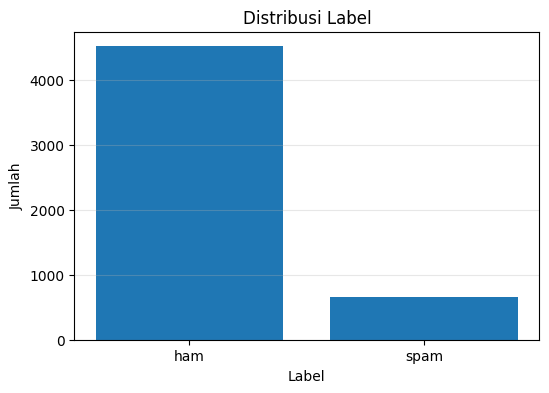

In [8]:
plt.figure(figsize=(6, 4))
plt.bar(eda_label_df.index, eda_label_df["count"])
plt.title("Distribusi Label")
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.grid(axis="y", alpha=0.3)
plt.show()

,text_length_char,text_length_word
count,5169.000000,5169.000000
mean,78.977945,15.340685
std,58.236293,11.068488
min,2.000000,1.000000
50%,60.000000,12.000000
75%,117.000000,22.000000
90%,155.000000,29.000000
95%,160.600000,32.000000
99%,264.920000,50.000000
max,910.000000,171.000000


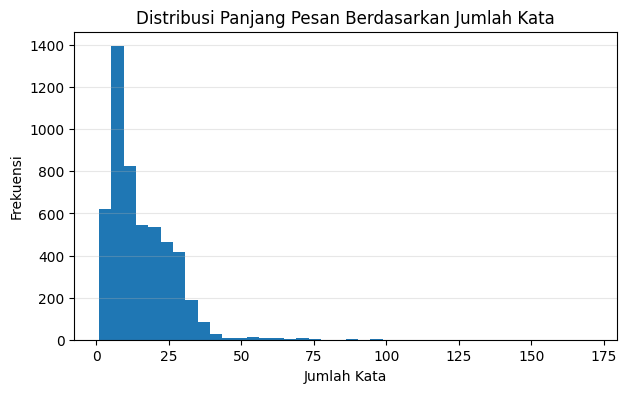

In [9]:
df["text_length_char"] = df["text"].str.len()
df["text_length_word"] = df["text"].str.split().apply(len)

display(
    df[["text_length_char", "text_length_word"]].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

plt.figure(figsize=(7, 4))
plt.hist(df["text_length_word"], bins=40)
plt.title("Distribusi Panjang Pesan Berdasarkan Jumlah Kata")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 5. Text Preprocessing

Preprocessing dibuat ringan karena pada tugas spam detection, beberapa token seperti angka, simbol uang, URL, kata promosi, dan pola singkat pada SMS bisa menjadi sinyal penting. Preprocessing yang terlalu agresif, seperti menghapus semua angka atau stopwords tanpa pertimbangan, dapat menghilangkan informasi yang berguna.

Strategi preprocessing pada notebook ini mempertahankan makna penting dari teks, sambil tetap membersihkan karakter yang tidak diperlukan. Angka, URL, dan simbol uang tidak sekadar dihapus, tetapi dinormalisasi agar model tetap mendapat sinyal bahwa pesan mengandung pola tertentu yang mungkin relevan untuk spam.


In [10]:
def clean_text(text):
    text = str(text).lower()

    # Normalisasi sinyal khusus yang sering muncul pada pesan spam.
    text = re.sub(r"http\S+|www\S+|https\S+", " url ", text)
    text = re.sub(r"\S+@\S+", " email ", text)
    text = re.sub(r"[£$€]", " money ", text)
    text = re.sub(r"\d+", " number ", text)

    # Hapus karakter selain huruf, angka, dan spasi.
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Rapikan spasi.
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_text"] = df["text"].apply(clean_text)

display(df[["label", "text", "clean_text"]].head())

,label,text,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in number a wkly comp to win fa cup...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


In [11]:
print("Contoh teks sebelum dan sesudah preprocessing:\n")

for i in range(min(5, len(df))):
    print("Original :", df.loc[i, "text"])
    print("Cleaned  :", df.loc[i, "clean_text"])
    print("-" * 80)

Contoh teks sebelum dan sesudah preprocessing:

Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned  : go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat
--------------------------------------------------------------------------------
Original : Ok lar... Joking wif u oni...
Cleaned  : ok lar joking wif u oni
--------------------------------------------------------------------------------
Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned  : free entry in number a wkly comp to win fa cup final tkts number st may number text fa to number to receive entry question std txt rate t c s apply number over number s
--------------------------------------------------------------------------------
Original : U dun say so early hor... U c already 

In [12]:
df["clean_text_length_word"] = df["clean_text"].str.split().apply(len)

display(
    df[["clean_text_length_word"]].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

,clean_text_length_word
count,5169.000000
mean,16.185529
std,11.786848
min,0.000000
50%,12.000000
75%,23.000000
90%,31.000000
95%,35.000000
99%,53.000000
max,190.000000


## 6. Train-Validation-Test Split

Split dilakukan secara stratified agar proporsi spam dan ham tetap mirip pada train, validation, dan test set. Berdasarkan output, jumlah data pada masing-masing subset adalah:

- train set: **3618 data**;
- validation set: **775 data**;
- test set: **776 data**.

Proporsi spam dan ham pada ketiga subset terlihat konsisten, yaitu sekitar **87.37% ham** dan **12.63% spam**. Selain itu, notebook juga memeriksa bahwa tidak ada overlap `row_id` antar subset. Ini berarti tidak ada data yang bocor dari train ke validation atau test set.


In [13]:
df["label_encoded"] = df["label"].map({"ham": 0, "spam": 1})

if df["label_encoded"].isna().any():
    raise ValueError("Ada label selain ham/spam. Periksa isi kolom label.")

X = df["clean_text"]
y = df["label_encoded"]
row_ids = df["row_id"]

X_train, X_temp, y_train, y_temp, id_train, id_temp = train_test_split(
    X,
    y,
    row_ids,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test, id_val, id_test = train_test_split(
    X_temp,
    y_temp,
    id_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train size      :", len(X_train))
print("Validation size :", len(X_val))
print("Test size       :", len(X_test))

split_distribution = pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "validation": y_val.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index()
})
split_distribution.index = ["ham", "spam"]
display(split_distribution)

Train size      : 3618
Validation size : 775
Test size       : 776


,train,validation,test
ham,0.873687,0.873548,0.873711
spam,0.126313,0.126452,0.126289


In [14]:
assert set(id_train).isdisjoint(set(id_val))
assert set(id_train).isdisjoint(set(id_test))
assert set(id_val).isdisjoint(set(id_test))

print("Tidak ada overlap row_id antar train, validation, dan test set.")

Tidak ada overlap row_id antar train, validation, dan test set.


## 7. Konfigurasi Eksperimen Baseline

Konfigurasi baseline dibuat sama untuk semua model agar perbandingan antar arsitektur lebih adil. Pada baseline, model menggunakan konfigurasi berikut:

- `max_words = 5000`;
- `max_sequence_length = 50`;
- `embedding_dim = 32`;
- `rnn_units = 32`;
- `dense_units = 16`;
- `batch_size = 32`;
- `epochs = 15` dengan EarlyStopping;
- optimizer Adam;
- loss function binary crossentropy.

Konfigurasi ini sengaja tidak dibuat terlalu besar karena dataset relatif kecil dan teks SMS cenderung pendek. Tujuannya adalah memperoleh baseline yang stabil sebelum melakukan hyperparameter tuning.


In [15]:
BASELINE_CONFIG = {
    "max_words": 5000,
    "max_sequence_length": 50,

    "embedding_dim": 32,
    "rnn_units": 32,
    "dense_units": 16,

    "embedding_dropout_rate": 0.10,
    "rnn_dropout_rate": 0.20,
    "recurrent_dropout_rate": 0.00,
    "dense_dropout_rate": 0.20,

    "batch_size": 32,
    "epochs": 15,

    "early_stopping_patience": 3,
    "early_stopping_min_delta": 0.0005,

    "learning_rate": 0.001,
    "threshold": 0.50
}

BASELINE_CONFIG

{'max_words': 5000,
 'max_sequence_length': 50,
 'embedding_dim': 32,
 'rnn_units': 32,
 'dense_units': 16,
 'embedding_dropout_rate': 0.1,
 'rnn_dropout_rate': 0.2,
 'recurrent_dropout_rate': 0.0,
 'dense_dropout_rate': 0.2,
 'batch_size': 32,
 'epochs': 15,
 'early_stopping_patience': 3,
 'early_stopping_min_delta': 0.0005,
 'learning_rate': 0.001,
 'threshold': 0.5}

### Tokenisasi dan Padding

Tokenizer hanya di-fit pada data train untuk menghindari data leakage. Validation dan test set kemudian ditransformasikan menggunakan tokenizer yang sama.

Padding dilakukan agar semua sequence memiliki panjang yang seragam. Pada notebook ini, layer Embedding menggunakan `mask_zero=True`, sehingga token padding bernilai 0 tidak dianggap sebagai kata oleh model. Ini penting untuk RNN, LSTM, BiLSTM, dan GRU karena tanpa masking, model dapat membaca padding sebagai bagian dari pola teks.


In [16]:
tokenizer = Tokenizer(
    num_words=BASELINE_CONFIG["max_words"],
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=BASELINE_CONFIG["max_sequence_length"],
    padding="post",
    truncating="post",
    value=0
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=BASELINE_CONFIG["max_sequence_length"],
    padding="post",
    truncating="post",
    value=0
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=BASELINE_CONFIG["max_sequence_length"],
    padding="post",
    truncating="post",
    value=0
)

y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

actual_spam_rate = float(np.mean(y_test))

print("X_train_pad shape:", X_train_pad.shape)
print("X_val_pad shape  :", X_val_pad.shape)
print("X_test_pad shape :", X_test_pad.shape)
print("Actual spam rate on test set:", actual_spam_rate)

X_train_pad shape: (3618, 50)
X_val_pad shape  : (775, 50)
X_test_pad shape : (776, 50)
Actual spam rate on test set: 0.12628865979381443


## 8. Fungsi Pembuatan Model dan Evaluasi

Bagian ini berisi fungsi modular agar baseline dan tuning menggunakan alur training serta evaluasi yang konsisten.

In [17]:
MODEL_TYPES = ["Simple RNN", "LSTM", "BiLSTM", "GRU"]

def get_callbacks(config):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=config["early_stopping_patience"],
            min_delta=config["early_stopping_min_delta"],
            restore_best_weights=True,
            verbose=1
        )
    ]


def build_sequence_model(model_type, config):
    model_type_lower = model_type.lower()

    inputs = Input(shape=(config["max_sequence_length"],), name="input_ids")

    x = Embedding(
        input_dim=config["max_words"],
        output_dim=config["embedding_dim"],
        mask_zero=True,
        name="embedding"
    )(inputs)

    x = Dropout(config["embedding_dropout_rate"], name="embedding_dropout")(x)

    if model_type_lower == "simple rnn":
        x = SimpleRNN(
            config["rnn_units"],
            dropout=config["rnn_dropout_rate"],
            recurrent_dropout=config.get("recurrent_dropout_rate", 0.0),
            name="simple_rnn"
        )(x)

    elif model_type_lower == "lstm":
        x = LSTM(
            config["rnn_units"],
            dropout=config["rnn_dropout_rate"],
            recurrent_dropout=config.get("recurrent_dropout_rate", 0.0),
            name="lstm"
        )(x)

    elif model_type_lower == "bilstm":
        x = Bidirectional(
            LSTM(
                config["rnn_units"],
                dropout=config["rnn_dropout_rate"],
                recurrent_dropout=config.get("recurrent_dropout_rate", 0.0)
            ),
            name="bilstm"
        )(x)

    elif model_type_lower == "gru":
        x = GRU(
            config["rnn_units"],
            dropout=config["rnn_dropout_rate"],
            recurrent_dropout=config.get("recurrent_dropout_rate", 0.0),
            name="gru"
        )(x)

    else:
        raise ValueError("model_type harus salah satu dari: Simple RNN, LSTM, BiLSTM, GRU")

    x = Dense(config["dense_units"], activation="relu", name="dense_hidden")(x)
    x = Dropout(config["dense_dropout_rate"], name="dense_dropout")(x)
    outputs = Dense(1, activation="sigmoid", name="output")(x)

    model = Model(inputs=inputs, outputs=outputs, name=model_type_lower.replace(" ", "_"))

    model.compile(
        optimizer=Adam(learning_rate=config["learning_rate"]),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


def plot_training_history(history, model_name):
    history_df = pd.DataFrame(history.history)
    epochs = np.arange(1, len(history_df) + 1)
    best_epoch = int(np.argmin(history_df["val_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history_df["loss"], marker="o", label="Training Loss")
    plt.plot(epochs, history_df["val_loss"], marker="o", label="Validation Loss")
    plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
    plt.title(f"Training vs Validation Loss - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history_df["accuracy"], marker="o", label="Training Accuracy")
    plt.plot(epochs, history_df["val_accuracy"], marker="o", label="Validation Accuracy")
    plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
    plt.title(f"Training vs Validation Accuracy - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [18]:
def diagnose_training_behavior(history, pred_spam_rate, f1_spam):
    hist = history.history

    train_loss_final_history = float(hist["loss"][-1])
    val_loss_final_history = float(hist["val_loss"][-1])
    train_acc_final_history = float(hist["accuracy"][-1])
    val_acc_final_history = float(hist["val_accuracy"][-1])

    best_epoch = int(np.argmin(hist["val_loss"]) + 1)
    best_val_loss = float(np.min(hist["val_loss"]))
    train_loss_at_best = float(hist["loss"][best_epoch - 1])
    train_acc_at_best = float(hist["accuracy"][best_epoch - 1])
    val_acc_at_best = float(hist["val_accuracy"][best_epoch - 1])

    final_loss_gap_history = val_loss_final_history - train_loss_final_history
    best_loss_gap = best_val_loss - train_loss_at_best
    best_acc_gap = train_acc_at_best - val_acc_at_best

    epochs_run = len(hist["loss"])
    epochs_after_best = epochs_run - best_epoch
    val_loss_worsening_ratio = val_loss_final_history / best_val_loss if best_val_loss > 0 else np.inf

    if pred_spam_rate < 0.02:
        diagnosis = "Model collapse ke kelas ham"
    elif pred_spam_rate > 0.98:
        diagnosis = "Model collapse ke kelas spam"
    elif f1_spam < 0.30:
        diagnosis = "Indikasi underfitting atau threshold belum cocok"
    elif epochs_after_best >= 2 and val_loss_worsening_ratio > 1.20:
        diagnosis = "Ada indikasi overfitting, dikontrol EarlyStopping"
    elif best_loss_gap > 0.10 or best_acc_gap > 0.06:
        diagnosis = "Overfitting ringan"
    else:
        diagnosis = "Relatif stabil"

    return {
        "Best Epoch": best_epoch,
        "Best Val Loss": best_val_loss,
        "Train Loss at Best Epoch": train_loss_at_best,
        "Best Loss Gap": float(best_loss_gap),
        "Best Accuracy Gap": float(best_acc_gap),
        "Final History Train Loss": train_loss_final_history,
        "Final History Val Loss": val_loss_final_history,
        "Final History Loss Gap": float(final_loss_gap_history),
        "Epochs After Best": int(epochs_after_best),
        "Val Loss Worsening Ratio": float(val_loss_worsening_ratio),
        "Training Diagnosis": diagnosis
    }


def evaluate_model(model, history, model_name, train_time, config, experiment_type="Baseline", show_plots=True):
    threshold = config["threshold"]

    val_eval = model.evaluate(X_val_pad, y_val, verbose=0, return_dict=True)
    test_eval = model.evaluate(X_test_pad, y_test, verbose=0, return_dict=True)

    y_prob = model.predict(X_test_pad, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    predicted_ham = int(np.sum(y_pred == 0))
    predicted_spam = int(np.sum(y_pred == 1))
    pred_spam_rate = float(predicted_spam / len(y_pred))

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    training_info = diagnose_training_behavior(history, pred_spam_rate, f1)

    result = {
        "Experiment Type": experiment_type,
        "Model": model_name,
        "Test Accuracy": acc,
        "Precision (Spam)": precision,
        "Recall (Spam)": recall,
        "F1-Score (Spam)": f1,
        "Validation Loss (Restored Best Weights)": float(val_eval["loss"]),
        "Validation Accuracy (Restored Best Weights)": float(val_eval["accuracy"]),
        "Test Loss": float(test_eval["loss"]),
        "Test Accuracy Keras": float(test_eval["accuracy"]),
        "Training Time (s)": float(train_time),
        "Epochs Run": len(history.history["loss"]),
        "Predicted Ham": predicted_ham,
        "Predicted Spam": predicted_spam,
        "Predicted Spam Rate": pred_spam_rate,
        "Actual Spam Rate": actual_spam_rate,
        **training_info
    }

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["ham", "spam"], zero_division=0))

    print("Confusion Matrix:")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {experiment_type} {model_name}")
    plt.show()

    print("Distribusi prediksi pada test set:")
    print(f"- Actual spam rate    : {actual_spam_rate:.4f}")
    print(f"- Predicted spam rate : {pred_spam_rate:.4f}")
    print(f"- Predicted ham       : {predicted_ham}")
    print(f"- Predicted spam      : {predicted_spam}")

    if pred_spam_rate < 0.02 or pred_spam_rate > 0.98:
        print("PERINGATAN: Model hampir memprediksi satu kelas saja. Hasil model ini tidak stabil.")

    print("\nDiagnosis training:", result["Training Diagnosis"])
    print(f"Best epoch berdasarkan validation loss: {result['Best Epoch']}")
    print("Catatan: evaluasi memakai bobot terbaik karena restore_best_weights=True.")

    return result


def evaluate_on_validation_for_tuning(model, config):
    threshold = config["threshold"]

    val_eval = model.evaluate(X_val_pad, y_val, verbose=0, return_dict=True)
    y_prob = model.predict(X_val_pad, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "Val Loss": float(val_eval["loss"]),
        "Val Accuracy": float(val_eval["accuracy"]),
        "Val Precision (Spam)": precision_score(y_val, y_pred, zero_division=0),
        "Val Recall (Spam)": recall_score(y_val, y_pred, zero_division=0),
        "Val F1-Score (Spam)": f1_score(y_val, y_pred, zero_division=0),
        "Val Predicted Spam Rate": float(np.mean(y_pred))
    }

## 9. Baseline Model Simple RNN

Simple RNN adalah arsitektur recurrent neural network paling dasar. Model ini memproses teks secara berurutan dari token pertama sampai token terakhir.

Kelebihan:

- lebih sederhana;
- waktu training relatif lebih cepat;
- cukup kuat untuk teks pendek.

Keterbatasan:

- kurang baik dalam menangkap dependensi jangka panjang;
- lebih rentan terhadap vanishing gradient dibanding LSTM dan GRU.

## 10. Baseline Model LSTM

LSTM atau Long Short-Term Memory dirancang untuk mengatasi kelemahan Simple RNN dalam menyimpan informasi jangka panjang. LSTM menggunakan mekanisme gate untuk mengatur informasi mana yang disimpan, dilupakan, dan diteruskan.

Kelebihan:

- lebih baik dalam menangkap konteks;
- lebih stabil dibanding Simple RNN pada sequence yang lebih panjang.

Keterbatasan:

- lebih kompleks;
- waktu training lebih lama daripada Simple RNN.

## 11. Baseline Model BiLSTM

BiLSTM menggunakan dua arah pemrosesan: forward dan backward. Artinya, model membaca sequence dari awal ke akhir dan dari akhir ke awal.

Kelebihan:

- dapat menangkap konteks dari dua arah;
- sering kuat untuk tugas klasifikasi teks.

Keterbatasan:

- parameter lebih banyak;
- waktu training biasanya lebih lama.

## 12. Baseline Model GRU

GRU atau Gated Recurrent Unit adalah varian recurrent neural network yang lebih sederhana daripada LSTM tetapi tetap memiliki mekanisme gate.

Kelebihan:

- lebih ringan daripada LSTM;
- sering memberikan performa yang kompetitif;
- waktu training cenderung lebih cepat.

Keterbatasan:

- dalam beberapa kasus, representasi konteksnya tidak sekuat LSTM atau BiLSTM.

## 13. Menjalankan Semua Eksperimen Baseline

Running baseline experiment: Simple RNN


Model: "simple_rnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 32)    │    160,000 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_dropout   │ (None, 50, 32)    │          0 │ embedding[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 50)        │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 32)        │      2,080 │ embedding_dropou… │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_hidden        │ (None, 16)        │        528 │ simple_rnn[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_dropout       │ (None, 16)        │          0 │ dense_hidden[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ dense_dropout[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 162,625 (635.25 KB)

 Trainable params: 162,625 (635.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6350 - loss: 0.5881 - val_accuracy: 0.9316 - val_loss: 0.2062
Epoch 2/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9244 - loss: 0.2578 - val_accuracy: 0.9677 - val_loss: 0.1010
Epoch 3/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9786 - loss: 0.0940 - val_accuracy: 0.9755 - val_loss: 0.0706
Epoch 4/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9735 - loss: 0.0797 - val_accuracy: 0.9781 - val_loss: 0.0737
Epoch 5/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9885 - loss: 0.0424 - val_accuracy: 0.9845 - val_loss: 0.0572
Epoch 6/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9934 - loss: 0.0321 - val_accuracy: 0.9845 - val_loss: 0.0604
Epoch 7/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9959 - loss: 0.0212 - val_accuracy: 0.9832 - val_loss: 0.0642
Epoch 8/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9980 - loss: 0.0136 - val_accu

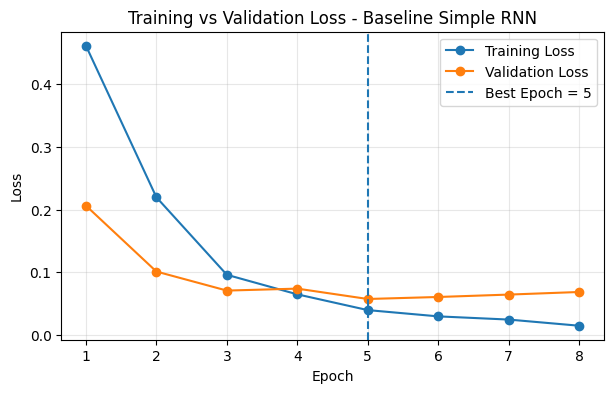

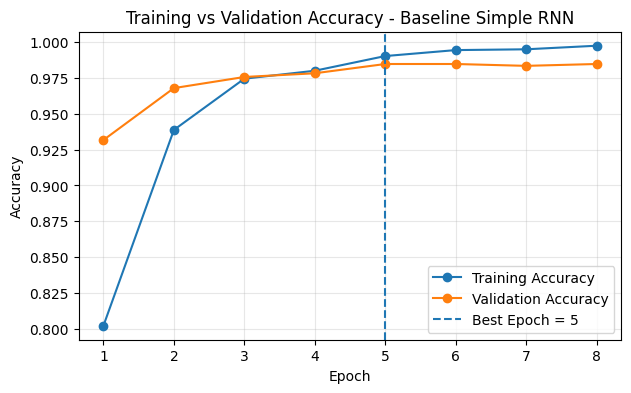


Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       678
        spam       0.92      0.93      0.92        98

    accuracy                           0.98       776
   macro avg       0.95      0.96      0.96       776
weighted avg       0.98      0.98      0.98       776

Confusion Matrix:


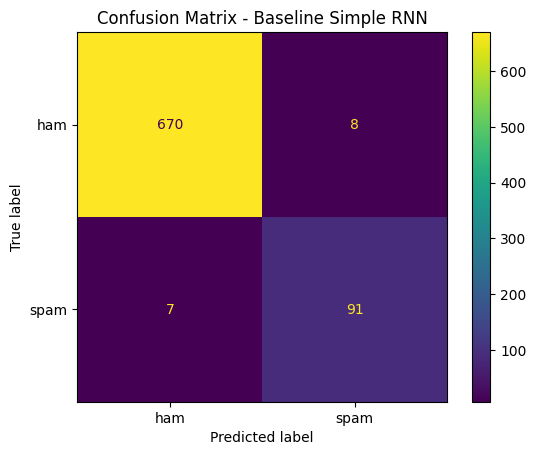

Distribusi prediksi pada test set:
- Actual spam rate    : 0.1263
- Predicted spam rate : 0.1276
- Predicted ham       : 677
- Predicted spam      : 99

Diagnosis training: Relatif stabil
Best epoch berdasarkan validation loss: 5
Catatan: evaluasi memakai bobot terbaik karena restore_best_weights=True.
Running baseline experiment: LSTM


Model: "lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 32)    │    160,000 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_dropout   │ (None, 50, 32)    │          0 │ embedding[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 50)        │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │      8,320 │ embedding_dropou… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_hidden        │ (None, 16)        │        528 │ lstm[0][0]        │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_dropout       │ (None, 16)        │          0 │ dense_hidden[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ dense_dropout[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 168,865 (659.63 KB)

 Trainable params: 168,865 (659.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8063 - loss: 0.5757 - val_accuracy: 0.9742 - val_loss: 0.1031
Epoch 2/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9762 - loss: 0.1070 - val_accuracy: 0.9832 - val_loss: 0.0668
Epoch 3/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9896 - loss: 0.0551 - val_accuracy: 0.9871 - val_loss: 0.0517
Epoch 4/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9934 - loss: 0.0397 - val_accuracy: 0.9871 - val_loss: 0.0513
Epoch 5/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9947 - loss: 0.0253 - val_accuracy: 0.9884 - val_loss: 0.0455
Epoch 6/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9968 - loss: 0.0174 - val_accuracy: 0.9884 - val_loss: 0.0547
Epoch 7/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9983 - loss: 0.0117 - val_accuracy: 0.9832 - val_loss: 0.0705
Epoch 8/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9987 - loss: 0.0081 - val_accu

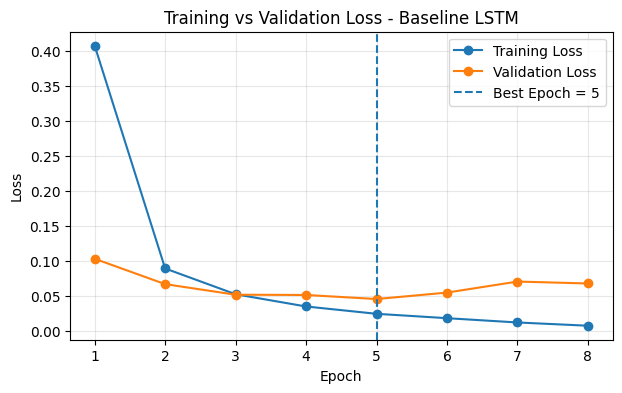

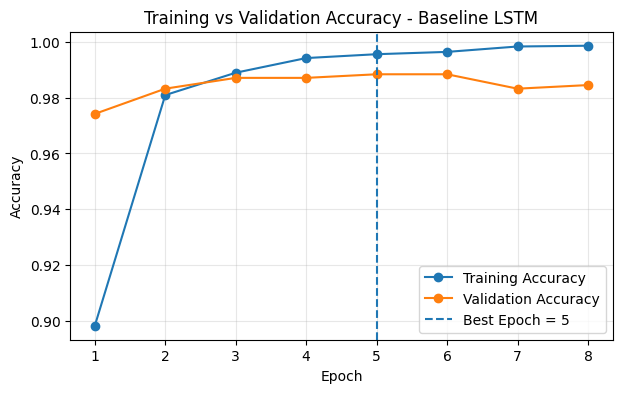


Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       678
        spam       0.94      0.94      0.94        98

    accuracy                           0.98       776
   macro avg       0.96      0.96      0.96       776
weighted avg       0.98      0.98      0.98       776

Confusion Matrix:


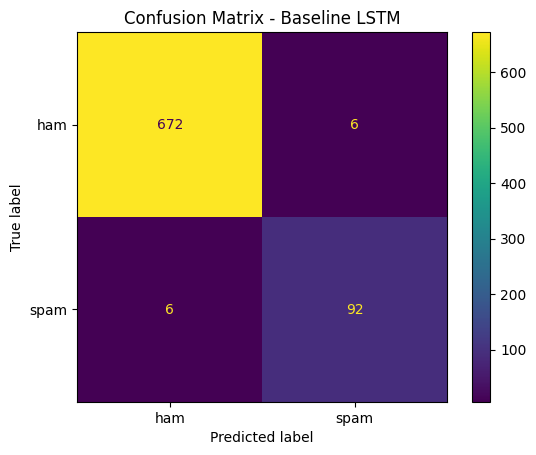

Distribusi prediksi pada test set:
- Actual spam rate    : 0.1263
- Predicted spam rate : 0.1263
- Predicted ham       : 678
- Predicted spam      : 98

Diagnosis training: Ada indikasi overfitting, dikontrol EarlyStopping
Best epoch berdasarkan validation loss: 5
Catatan: evaluasi memakai bobot terbaik karena restore_best_weights=True.
Running baseline experiment: BiLSTM


Model: "bilstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 32)    │    160,000 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_dropout   │ (None, 50, 32)    │          0 │ embedding[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 50)        │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 64)        │     16,640 │ embedding_dropou… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_hidden        │ (None, 16)        │      1,040 │ bilstm[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_dropout       │ (None, 16)        │          0 │ dense_hidden[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ dense_dropout[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 177,697 (694.13 KB)

 Trainable params: 177,697 (694.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.8702 - loss: 0.4894 - val_accuracy: 0.9703 - val_loss: 0.1031
Epoch 2/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9809 - loss: 0.0757 - val_accuracy: 0.9858 - val_loss: 0.0511
Epoch 3/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9924 - loss: 0.0335 - val_accuracy: 0.9871 - val_loss: 0.0464
Epoch 4/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9953 - loss: 0.0231 - val_accuracy: 0.9871 - val_loss: 0.0435
Epoch 5/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9972 - loss: 0.0133 - val_accuracy: 0.9871 - val_loss: 0.0436
Epoch 6/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9991 - loss: 0.0070 - val_accuracy: 0.9794 - val_loss: 0.0908
Epoch 7/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9991 - loss: 0.0054 - val_accuracy: 0.9781 - val_loss: 0.1296
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.

Training time

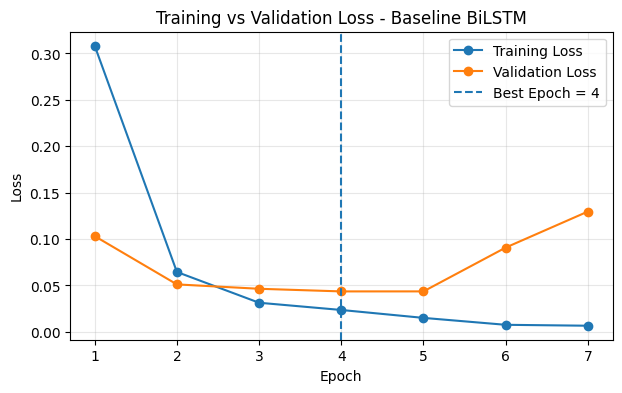

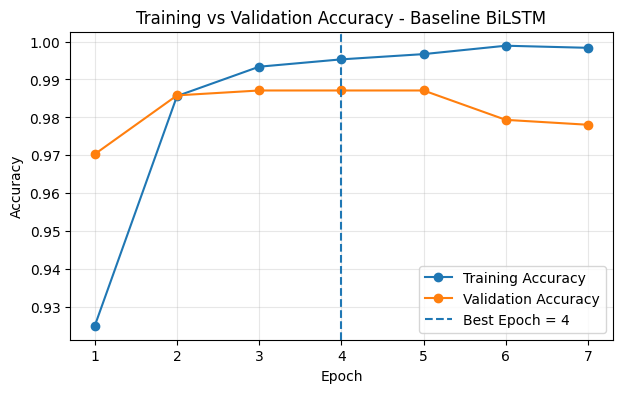


Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       678
        spam       0.96      0.93      0.94        98

    accuracy                           0.99       776
   macro avg       0.97      0.96      0.97       776
weighted avg       0.99      0.99      0.99       776

Confusion Matrix:


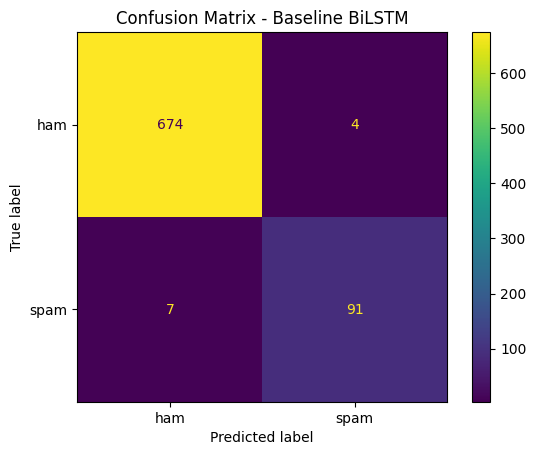

Distribusi prediksi pada test set:
- Actual spam rate    : 0.1263
- Predicted spam rate : 0.1224
- Predicted ham       : 681
- Predicted spam      : 95

Diagnosis training: Ada indikasi overfitting, dikontrol EarlyStopping
Best epoch berdasarkan validation loss: 4
Catatan: evaluasi memakai bobot terbaik karena restore_best_weights=True.
Running baseline experiment: GRU


Model: "gru"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 32)    │    160,000 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_dropout   │ (None, 50, 32)    │          0 │ embedding[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 50)        │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 32)        │      6,336 │ embedding_dropou… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_hidden        │ (None, 16)        │        528 │ gru[0][0]         │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_dropout       │ (None, 16)        │          0 │ dense_hidden[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ dense_dropout[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 166,881 (651.88 KB)

 Trainable params: 166,881 (651.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.7732 - loss: 0.5747 - val_accuracy: 0.9677 - val_loss: 0.1157
Epoch 2/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9704 - loss: 0.1180 - val_accuracy: 0.9806 - val_loss: 0.0651
Epoch 3/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9872 - loss: 0.0572 - val_accuracy: 0.9819 - val_loss: 0.0548
Epoch 4/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9928 - loss: 0.0367 - val_accuracy: 0.9858 - val_loss: 0.0574
Epoch 5/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9959 - loss: 0.0204 - val_accuracy: 0.9845 - val_loss: 0.0666
Epoch 6/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9976 - loss: 0.0140 - val_accuracy: 0.9845 - val_loss: 0.0767
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.

Training time GRU: 20.80 seconds


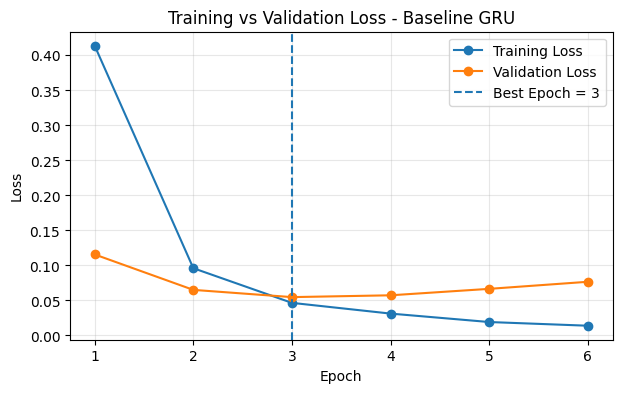

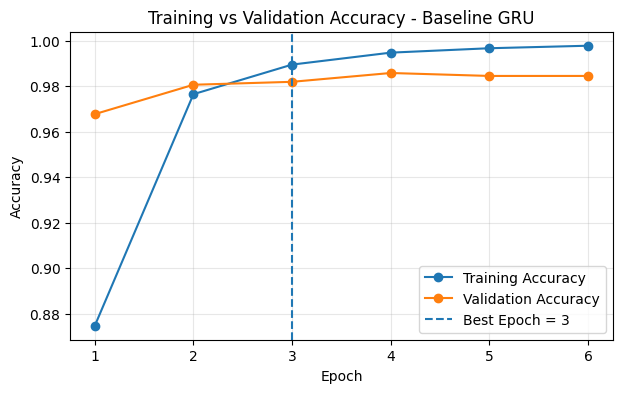


Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       678
        spam       0.92      0.94      0.93        98

    accuracy                           0.98       776
   macro avg       0.96      0.96      0.96       776
weighted avg       0.98      0.98      0.98       776

Confusion Matrix:


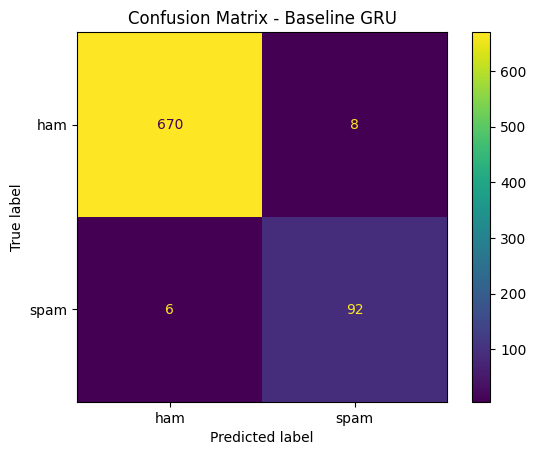

Distribusi prediksi pada test set:
- Actual spam rate    : 0.1263
- Predicted spam rate : 0.1289
- Predicted ham       : 676
- Predicted spam      : 100

Diagnosis training: Ada indikasi overfitting, dikontrol EarlyStopping
Best epoch berdasarkan validation loss: 3
Catatan: evaluasi memakai bobot terbaik karena restore_best_weights=True.


In [20]:
def run_baseline_experiment(model_type):
    print("=" * 80)
    print(f"Running baseline experiment: {model_type}")
    print("=" * 80)

    tf.keras.backend.clear_session()
    set_global_seed(RANDOM_STATE)

    model = build_sequence_model(model_type, BASELINE_CONFIG)
    model.summary()

    start_time = time.time()

    history = model.fit(
        X_train_pad,
        y_train,
        validation_data=(X_val_pad, y_val),
        epochs=BASELINE_CONFIG["epochs"],
        batch_size=BASELINE_CONFIG["batch_size"],
        callbacks=get_callbacks(BASELINE_CONFIG),
        verbose=1
    )

    train_time = time.time() - start_time
    print(f"\nTraining time {model_type}: {train_time:.2f} seconds")

    plot_training_history(history, f"Baseline {model_type}")

    result = evaluate_model(
        model=model,
        history=history,
        model_name=model_type,
        train_time=train_time,
        config=BASELINE_CONFIG,
        experiment_type="Baseline"
    )

    baseline_histories[model_type] = history
    baseline_models[model_type] = model
    baseline_results.append(result)

    return model, history, result


baseline_histories = {}
baseline_models = {}
baseline_results = []

for model_type in MODEL_TYPES:
    run_baseline_experiment(model_type)

## 14. Evaluasi Semua Model Baseline

In [23]:
baseline_results_df = pd.DataFrame(baseline_results)

baseline_metric_columns = [
    "Experiment Type",
    "Model",
    "Test Accuracy",
    "Precision (Spam)",
    "Recall (Spam)",
    "F1-Score (Spam)",
    "Validation Loss (Restored Best Weights)",
    "Test Loss",
    "Training Time (s)",
    "Epochs Run",
    "Predicted Spam Rate",
    "Actual Spam Rate",
    "Best Epoch",
    "Best Val Loss",
    "Best Loss Gap",
    "Epochs After Best",
    "Val Loss Worsening Ratio",
    "Training Diagnosis"
]

baseline_results_df = baseline_results_df[baseline_metric_columns].copy()

rounded_baseline_results_df = baseline_results_df.copy()
numeric_cols = rounded_baseline_results_df.select_dtypes(include=["float64", "float32"]).columns
rounded_baseline_results_df[numeric_cols] = rounded_baseline_results_df[numeric_cols].round(4)

display(rounded_baseline_results_df)

,Experiment Type,Model,Test Accuracy,Precision (Spam),Recall (Spam),F1-Score (Spam),Validation Loss (Restored Best Weights),Test Loss,Training Time (s),Epochs Run,Predicted Spam Rate,Actual Spam Rate,Best Epoch,Best Val Loss,Best Loss Gap,Epochs After Best,Val Loss Worsening Ratio,Training Diagnosis
0,Baseline,Simple RNN,0.9807,0.9192,0.9286,0.9239,0.0572,0.0732,17.6668,8,0.1276,0.1263,5,0.0572,0.0177,3,1.1954,Relatif stabil
1,Baseline,LSTM,0.9845,0.9388,0.9388,0.9388,0.0455,0.0555,25.9761,8,0.1263,0.1263,5,0.0455,0.0211,3,1.4898,"Ada indikasi overfitting, dikontrol EarlyStopping"
2,Baseline,BiLSTM,0.9858,0.9579,0.9286,0.9430,0.0435,0.0441,32.6371,7,0.1224,0.1263,4,0.0435,0.0200,3,2.9762,"Ada indikasi overfitting, dikontrol EarlyStopping"
3,Baseline,GRU,0.9820,0.9200,0.9388,0.9293,0.0548,0.0703,20.8010,6,0.1289,0.1263,3,0.0548,0.0082,3,1.3998,"Ada indikasi overfitting, dikontrol EarlyStopping"


### Interpretasi Tabel Baseline

Berdasarkan tabel baseline, **BiLSTM** menjadi model baseline terbaik secara keseluruhan. Model ini memperoleh accuracy **0.9858**, precision spam **0.9579**, F1-score spam **0.9430**, dan test loss **0.0441**. Nilai ini menunjukkan bahwa BiLSTM paling kuat pada tahap baseline, terutama karena mampu menjaga false positive tetap rendah.

Namun, baseline BiLSTM bukan tanpa trade-off. Waktu training-nya paling lama, yaitu sekitar **32.64 detik**, dan validation loss worsening ratio-nya paling tinggi. Ini menunjukkan adanya indikasi overfitting setelah epoch terbaik, walaupun sudah dikontrol dengan EarlyStopping.

Baseline **LSTM** dan **GRU** sama-sama memiliki recall spam tertinggi, yaitu **0.9388**. Artinya, keduanya menangkap proporsi spam yang sama besar pada test set. Akan tetapi, LSTM lebih unggul dari GRU karena F1-score dan test loss-nya lebih baik.

Baseline **Simple RNN** menjadi model tercepat dan relatif stabil, tetapi memiliki F1-score spam paling rendah di antara baseline model. Ini masuk akal karena Simple RNN adalah arsitektur paling sederhana.


In [24]:
baseline_results_df.to_csv("baseline_results.csv", index=False)
print("Hasil baseline disimpan ke baseline_results.csv")

Hasil baseline disimpan ke baseline_results.csv


## 15. Visualisasi Perbandingan Baseline

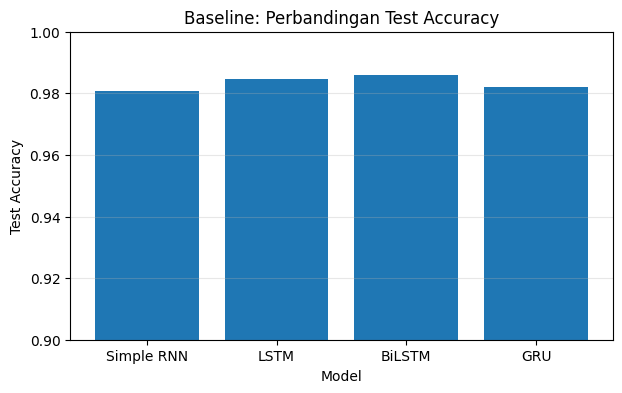

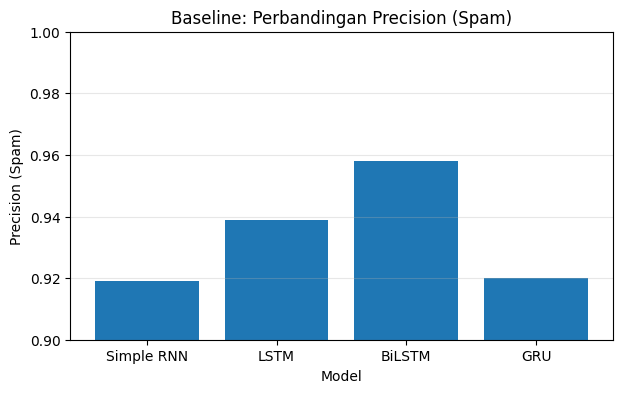

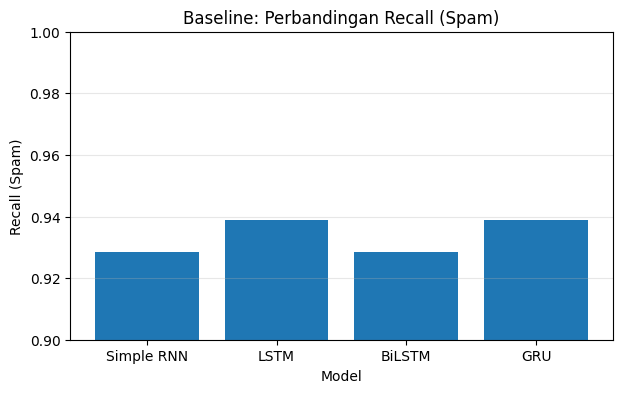

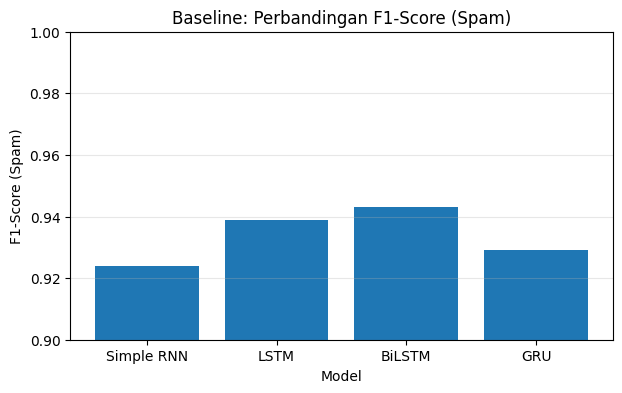

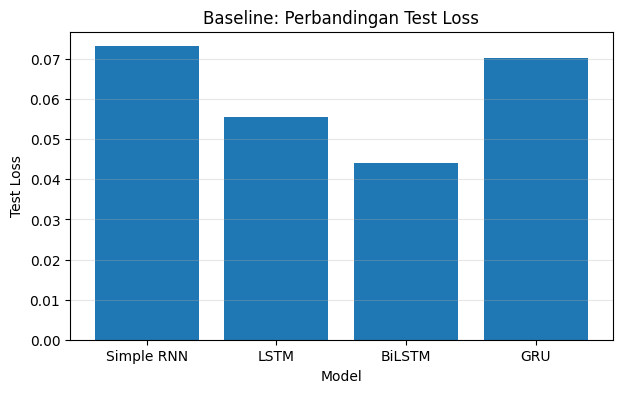

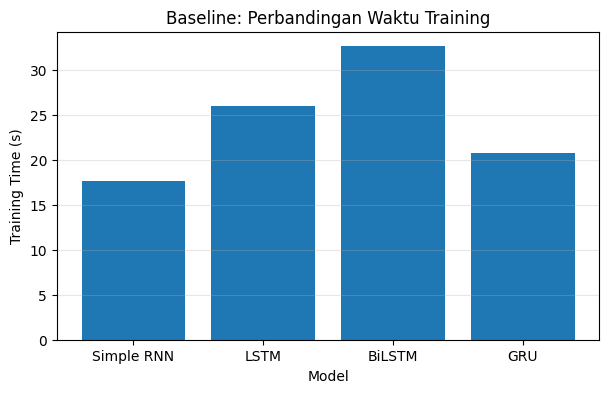

In [28]:
performance_metrics = [
    "Test Accuracy",
    "Precision (Spam)",
    "Recall (Spam)",
    "F1-Score (Spam)"
]

for metric in performance_metrics:
    plt.figure(figsize=(7, 4))
    plt.bar(baseline_results_df["Model"], baseline_results_df[metric])
    plt.title(f"Baseline: Perbandingan {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.ylim(0.9, 1.0)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

plt.figure(figsize=(7, 4))
plt.bar(baseline_results_df["Model"], baseline_results_df["Test Loss"])
plt.title("Baseline: Perbandingan Test Loss")
plt.xlabel("Model")
plt.ylabel("Test Loss")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(baseline_results_df["Model"], baseline_results_df["Training Time (s)"])
plt.title("Baseline: Perbandingan Waktu Training")
plt.xlabel("Model")
plt.ylabel("Training Time (s)")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 16. Analisis Awal Baseline

Bagian ini menampilkan ringkasan otomatis berdasarkan tabel baseline. Interpretasi utama dari output baseline adalah:

- **BiLSTM** menjadi model baseline terbaik berdasarkan F1-score spam, precision spam, accuracy, dan test loss.
- **LSTM** dan **GRU** memiliki recall spam tertinggi yang sama pada baseline, yaitu **0.9388**.
- **Simple RNN** menjadi model tercepat dan relatif stabil, tetapi F1-score spam baseline-nya paling rendah dibanding model lain.
- Predicted spam rate semua model mendekati actual spam rate, sehingga tidak ada indikasi model collapse ke satu kelas.

Dengan demikian, baseline sudah cukup sehat untuk dijadikan pembanding terhadap tuned model.


In [29]:
def print_best_models(result_df, title="Ringkasan Model Terbaik"):
    print("=" * 80)
    print(title)
    print("=" * 80)

    metrics_to_check = {
        "F1-score spam tertinggi": "F1-Score (Spam)",
        "Recall spam tertinggi": "Recall (Spam)",
        "Precision spam tertinggi": "Precision (Spam)",
        "Test loss terendah": "Test Loss",
        "Training time tercepat": "Training Time (s)"
    }

    for label, metric in metrics_to_check.items():
        if metric == "Test Loss" or metric == "Training Time (s)":
            best_value = result_df[metric].min()
        else:
            best_value = result_df[metric].max()

        winners = result_df[np.isclose(result_df[metric], best_value)]["Model"].tolist()
        print(f"{label}: {', '.join(winners)} ({metric} = {best_value:.4f})")

print_best_models(baseline_results_df, title="Ringkasan Baseline")

Ringkasan Baseline
F1-score spam tertinggi: BiLSTM (F1-Score (Spam) = 0.9430)
Recall spam tertinggi: LSTM, GRU (Recall (Spam) = 0.9388)
Precision spam tertinggi: BiLSTM (Precision (Spam) = 0.9579)
Test loss terendah: BiLSTM (Test Loss = 0.0441)
Training time tercepat: Simple RNN (Training Time (s) = 17.6668)


In [30]:
for _, row in baseline_results_df.iterrows():
    print("=" * 80)
    print(f"{row['Experiment Type']} - {row['Model']}")
    print(f"- Diagnosis training       : {row['Training Diagnosis']}")
    print(f"- Best epoch               : {row['Best Epoch']}")
    print(f"- Epochs after best        : {row['Epochs After Best']}")
    print(f"- Best loss gap            : {row['Best Loss Gap']:.4f}")
    print(f"- Val loss worsening ratio : {row['Val Loss Worsening Ratio']:.4f}")
    print(f"- Predicted spam rate      : {row['Predicted Spam Rate']:.4f}")
    print(f"- F1-score spam            : {row['F1-Score (Spam)']:.4f}")

Baseline - Simple RNN
- Diagnosis training       : Relatif stabil
- Best epoch               : 5
- Epochs after best        : 3
- Best loss gap            : 0.0177
- Val loss worsening ratio : 1.1954
- Predicted spam rate      : 0.1276
- F1-score spam            : 0.9239
Baseline - LSTM
- Diagnosis training       : Ada indikasi overfitting, dikontrol EarlyStopping
- Best epoch               : 5
- Epochs after best        : 3
- Best loss gap            : 0.0211
- Val loss worsening ratio : 1.4898
- Predicted spam rate      : 0.1263
- F1-score spam            : 0.9388
Baseline - BiLSTM
- Diagnosis training       : Ada indikasi overfitting, dikontrol EarlyStopping
- Best epoch               : 4
- Epochs after best        : 3
- Best loss gap            : 0.0200
- Val loss worsening ratio : 2.9762
- Predicted spam rate      : 0.1224
- F1-score spam            : 0.9430
Baseline - GRU
- Diagnosis training       : Ada indikasi overfitting, dikontrol EarlyStopping
- Best epoch               : 3

### Analisis Overfitting pada Baseline

Output diagnosis training menunjukkan bahwa **Simple RNN relatif stabil**, sedangkan **LSTM, BiLSTM, dan GRU memiliki indikasi overfitting yang dikontrol oleh EarlyStopping**.

Hal ini terlihat dari adanya jarak antara training loss dan validation loss setelah epoch terbaik. Namun, karena `restore_best_weights=True`, model yang dievaluasi pada test set menggunakan bobot terbaik dari validation loss, bukan bobot pada epoch terakhir.

Dengan demikian, overfitting memang terdeteksi, tetapi belum merusak performa test. Ini terlihat dari F1-score spam semua baseline yang masih berada di atas **0.92** dan predicted spam rate yang tetap dekat dengan actual spam rate.


## 17. Konfigurasi Hyperparameter Tuning

Tuning dilakukan secara **terarah dan terbatas**, bukan exhaustive besar-besaran. Hal ini penting karena dataset relatif kecil. Jika search space terlalu luas, model berisiko terlalu cocok pada validation set dan hasil akhirnya menjadi kurang generalizable.

Notebook ini menggunakan 6 kombinasi hyperparameter untuk setiap model. Parameter yang diuji meliputi:

- `embedding_dim`;
- `rnn_units`;
- `dense_units`;
- `embedding_dropout_rate`;
- `rnn_dropout_rate`;
- `dense_dropout_rate`;
- `learning_rate`;
- `batch_size`.

Semua model diuji dengan search space yang sama agar proses tuning tetap adil.


In [39]:
TUNING_SEARCH_SPACE = [
    {
        "embedding_dim": 32,
        "rnn_units": 32,
        "dense_units": 16,
        "embedding_dropout_rate": 0.10,
        "rnn_dropout_rate": 0.20,
        "dense_dropout_rate": 0.20,
        "learning_rate": 0.001,
        "batch_size": 32
    },
    {
        "embedding_dim": 64,
        "rnn_units": 32,
        "dense_units": 16,
        "embedding_dropout_rate": 0.10,
        "rnn_dropout_rate": 0.20,
        "dense_dropout_rate": 0.20,
        "learning_rate": 0.001,
        "batch_size": 32
    },
    {
        "embedding_dim": 32,
        "rnn_units": 64,
        "dense_units": 32,
        "embedding_dropout_rate": 0.10,
        "rnn_dropout_rate": 0.20,
        "dense_dropout_rate": 0.30,
        "learning_rate": 0.001,
        "batch_size": 32
    },
    {
        "embedding_dim": 64,
        "rnn_units": 64,
        "dense_units": 32,
        "embedding_dropout_rate": 0.15,
        "rnn_dropout_rate": 0.30,
        "dense_dropout_rate": 0.30,
        "learning_rate": 0.0005,
        "batch_size": 32
    },
    {
        "embedding_dim": 32,
        "rnn_units": 32,
        "dense_units": 16,
        "embedding_dropout_rate": 0.20,
        "rnn_dropout_rate": 0.30,
        "dense_dropout_rate": 0.40,
        "learning_rate": 0.0005,
        "batch_size": 64
    },
    {
        "embedding_dim": 64,
        "rnn_units": 32,
        "dense_units": 32,
        "embedding_dropout_rate": 0.15,
        "rnn_dropout_rate": 0.30,
        "dense_dropout_rate": 0.30,
        "learning_rate": 0.001,
        "batch_size": 64
    }
]

TUNING_CONFIG = {
    "epochs": 15,
    "early_stopping_patience": 3,
    "early_stopping_min_delta": 0.0005,
    "max_trials_per_model": len(TUNING_SEARCH_SPACE),
    "selection_metric": "Val F1-Score (Spam)"
}

pd.DataFrame(TUNING_SEARCH_SPACE)

,embedding_dim,rnn_units,dense_units,embedding_dropout_rate,rnn_dropout_rate,dense_dropout_rate,learning_rate,batch_size
0,32,32,16,0.10,0.2,0.2,0.0010,32
1,64,32,16,0.10,0.2,0.2,0.0010,32
2,32,64,32,0.10,0.2,0.3,0.0010,32
3,64,64,32,0.15,0.3,0.3,0.0005,32
4,32,32,16,0.20,0.3,0.4,0.0005,64
5,64,32,32,0.15,0.3,0.3,0.0010,64


## 18. Fungsi Hyperparameter Tuning

Setiap trial dilatih menggunakan train set dan dipantau menggunakan validation set. Pemilihan hyperparameter terbaik dilakukan berdasarkan **F1-score spam pada validation set**, bukan berdasarkan test set.

Prinsip ini penting: test set hanya boleh digunakan pada evaluasi akhir. Jika test set digunakan untuk memilih hyperparameter, maka hasil evaluasi final menjadi bias karena model secara tidak langsung sudah dipilih berdasarkan performa pada test set.


In [40]:
def make_trial_config(params):
    trial_config = deepcopy(BASELINE_CONFIG)
    trial_config.update(params)
    trial_config["epochs"] = TUNING_CONFIG["epochs"]
    trial_config["early_stopping_patience"] = TUNING_CONFIG["early_stopping_patience"]
    trial_config["early_stopping_min_delta"] = TUNING_CONFIG["early_stopping_min_delta"]
    return trial_config


def tune_model(model_type):
    print("=" * 80)
    print(f"Hyperparameter tuning: {model_type}")
    print("=" * 80)

    trial_records = []
    best_score = -np.inf
    best_record = None

    for trial_idx, params in enumerate(TUNING_SEARCH_SPACE, start=1):
        print("-" * 80)
        print(f"Trial {trial_idx}/{len(TUNING_SEARCH_SPACE)} - {model_type}")
        print(params)

        tf.keras.backend.clear_session()
        set_global_seed(RANDOM_STATE + trial_idx)

        trial_config = make_trial_config(params)
        model = build_sequence_model(model_type, trial_config)

        start_time = time.time()

        history = model.fit(
            X_train_pad,
            y_train,
            validation_data=(X_val_pad, y_val),
            epochs=trial_config["epochs"],
            batch_size=trial_config["batch_size"],
            callbacks=get_callbacks(trial_config),
            verbose=0
        )

        train_time = time.time() - start_time
        val_metrics = evaluate_on_validation_for_tuning(model, trial_config)

        record = {
            "Model": model_type,
            "Trial": trial_idx,
            **params,
            **val_metrics,
            "Epochs Run": len(history.history["loss"]),
            "Best Epoch": int(np.argmin(history.history["val_loss"]) + 1),
            "Training Time (s)": float(train_time)
        }

        trial_records.append(record)

        print(
            f"Val F1={record['Val F1-Score (Spam)']:.4f} | "
            f"Val Loss={record['Val Loss']:.4f} | "
            f"Epochs={record['Epochs Run']} | "
            f"Time={record['Training Time (s)']:.2f}s"
        )

        current_score = record[TUNING_CONFIG["selection_metric"]]
        if current_score > best_score:
            best_score = current_score
            best_record = record

        del model
        gc.collect()

    tuning_df = pd.DataFrame(trial_records).sort_values(
        by=[TUNING_CONFIG["selection_metric"], "Val Loss"],
        ascending=[False, True]
    ).reset_index(drop=True)

    print("\nBest trial berdasarkan validation F1-score:")
    display(pd.DataFrame([best_record]))

    return tuning_df, best_record

## 19. Hyperparameter Tuning Simple RNN

In [41]:
simple_rnn_tuning_df, simple_rnn_best = tune_model("Simple RNN")
display(simple_rnn_tuning_df)

Hyperparameter tuning: Simple RNN
--------------------------------------------------------------------------------
Trial 1/6 - Simple RNN
{'embedding_dim': 32, 'rnn_units': 32, 'dense_units': 16, 'embedding_dropout_rate': 0.1, 'rnn_dropout_rate': 0.2, 'dense_dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32}
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Val F1=0.9381 | Val Loss=0.0541 | Epochs=6 | Time=13.59s
--------------------------------------------------------------------------------
Trial 2/6 - Simple RNN
{'embedding_dim': 64, 'rnn_units': 32, 'dense_units': 16, 'embedding_dropout_rate': 0.1, 'rnn_dropout_rate': 0.2, 'dense_dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32}
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 5.
Val F1=0.9418 | Val Loss=0.0515 | Epochs=8 | Time=17.76s
--------------------------------------------------------------------------------
Trial 3/6 - Simple RNN
{'embedd

,Model,Trial,embedding_dim,rnn_units,dense_units,embedding_dropout_rate,rnn_dropout_rate,dense_dropout_rate,learning_rate,batch_size,Val Loss,Val Accuracy,Val Precision (Spam),Val Recall (Spam),Val F1-Score (Spam),Val Predicted Spam Rate,Epochs Run,Best Epoch,Training Time (s)
0,Simple RNN,3,32,64,32,0.1,0.2,0.3,0.001,32,0.041347,0.989677,0.98913,0.928571,0.957895,0.11871,7,4,15.845228


,Model,Trial,embedding_dim,rnn_units,dense_units,embedding_dropout_rate,rnn_dropout_rate,dense_dropout_rate,learning_rate,batch_size,Val Loss,Val Accuracy,Val Precision (Spam),Val Recall (Spam),Val F1-Score (Spam),Val Predicted Spam Rate,Epochs Run,Best Epoch,Training Time (s)
0,Simple RNN,3,32,64,32,0.10,0.2,0.3,0.0010,32,0.041347,0.989677,0.989130,0.928571,0.957895,0.118710,7,4,15.845228
1,Simple RNN,4,64,64,32,0.15,0.3,0.3,0.0005,32,0.047624,0.989677,0.989130,0.928571,0.957895,0.118710,8,5,18.444130
2,Simple RNN,5,32,32,16,0.20,0.3,0.4,0.0005,64,0.054231,0.987097,0.978261,0.918367,0.947368,0.118710,14,11,16.727324
3,Simple RNN,2,64,32,16,0.10,0.2,0.2,0.0010,32,0.051543,0.985806,0.978022,0.908163,0.941799,0.117419,8,5,17.759136
4,Simple RNN,6,64,32,32,0.15,0.3,0.3,0.0010,64,0.059988,0.985806,0.978022,0.908163,0.941799,0.117419,7,4,10.554966
5,Simple RNN,1,32,32,16,0.10,0.2,0.2,0.0010,32,0.054059,0.984516,0.947917,0.928571,0.938144,0.123871,6,3,13.587183


## 20. Hyperparameter Tuning LSTM

In [42]:
lstm_tuning_df, lstm_best = tune_model("LSTM")
display(lstm_tuning_df)

Hyperparameter tuning: LSTM
--------------------------------------------------------------------------------
Trial 1/6 - LSTM
{'embedding_dim': 32, 'rnn_units': 32, 'dense_units': 16, 'embedding_dropout_rate': 0.1, 'rnn_dropout_rate': 0.2, 'dense_dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32}
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Val F1=0.9436 | Val Loss=0.0464 | Epochs=6 | Time=19.62s
--------------------------------------------------------------------------------
Trial 2/6 - LSTM
{'embedding_dim': 64, 'rnn_units': 32, 'dense_units': 16, 'embedding_dropout_rate': 0.1, 'rnn_dropout_rate': 0.2, 'dense_dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32}
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.
Val F1=0.9524 | Val Loss=0.0576 | Epochs=7 | Time=23.31s
--------------------------------------------------------------------------------
Trial 3/6 - LSTM
{'embedding_dim': 32, 'rnn_units

,Model,Trial,embedding_dim,rnn_units,dense_units,embedding_dropout_rate,rnn_dropout_rate,dense_dropout_rate,learning_rate,batch_size,Val Loss,Val Accuracy,Val Precision (Spam),Val Recall (Spam),Val F1-Score (Spam),Val Predicted Spam Rate,Epochs Run,Best Epoch,Training Time (s)
0,LSTM,6,64,32,32,0.15,0.3,0.3,0.001,64,0.044433,0.990968,0.989247,0.938776,0.963351,0.12,9,6,18.256705


,Model,Trial,embedding_dim,rnn_units,dense_units,embedding_dropout_rate,rnn_dropout_rate,dense_dropout_rate,learning_rate,batch_size,Val Loss,Val Accuracy,Val Precision (Spam),Val Recall (Spam),Val F1-Score (Spam),Val Predicted Spam Rate,Epochs Run,Best Epoch,Training Time (s)
0,LSTM,6,64,32,32,0.15,0.3,0.3,0.0010,64,0.044433,0.990968,0.989247,0.938776,0.963351,0.120000,9,6,18.256705
1,LSTM,4,64,64,32,0.15,0.3,0.3,0.0005,32,0.043574,0.988387,0.989011,0.918367,0.952381,0.117419,11,8,39.976938
2,LSTM,3,32,64,32,0.10,0.2,0.3,0.0010,32,0.044154,0.988387,0.989011,0.918367,0.952381,0.117419,8,5,28.785691
3,LSTM,2,64,32,16,0.10,0.2,0.2,0.0010,32,0.057588,0.988387,0.989011,0.918367,0.952381,0.117419,7,4,23.311875
4,LSTM,5,32,32,16,0.20,0.3,0.4,0.0005,64,0.053491,0.987097,0.968085,0.928571,0.947917,0.121290,13,10,23.614759
5,LSTM,1,32,32,16,0.10,0.2,0.2,0.0010,32,0.046382,0.985806,0.948454,0.938776,0.943590,0.125161,6,3,19.617553


## 21. Hyperparameter Tuning BiLSTM

In [43]:
bilstm_tuning_df, bilstm_best = tune_model("BiLSTM")
display(bilstm_tuning_df)

Hyperparameter tuning: BiLSTM
--------------------------------------------------------------------------------
Trial 1/6 - BiLSTM
{'embedding_dim': 32, 'rnn_units': 32, 'dense_units': 16, 'embedding_dropout_rate': 0.1, 'rnn_dropout_rate': 0.2, 'dense_dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32}
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Val F1=0.9524 | Val Loss=0.0416 | Epochs=6 | Time=28.16s
--------------------------------------------------------------------------------
Trial 2/6 - BiLSTM
{'embedding_dim': 64, 'rnn_units': 32, 'dense_units': 16, 'embedding_dropout_rate': 0.1, 'rnn_dropout_rate': 0.2, 'dense_dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32}
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Val F1=0.9239 | Val Loss=0.0556 | Epochs=6 | Time=29.84s
--------------------------------------------------------------------------------
Trial 3/6 - BiLSTM
{'embedding_dim': 32, 'r

,Model,Trial,embedding_dim,rnn_units,dense_units,embedding_dropout_rate,rnn_dropout_rate,dense_dropout_rate,learning_rate,batch_size,Val Loss,Val Accuracy,Val Precision (Spam),Val Recall (Spam),Val F1-Score (Spam),Val Predicted Spam Rate,Epochs Run,Best Epoch,Training Time (s)
0,BiLSTM,6,64,32,32,0.15,0.3,0.3,0.001,64,0.04064,0.990968,0.978947,0.94898,0.963731,0.122581,12,9,33.012149


,Model,Trial,embedding_dim,rnn_units,dense_units,embedding_dropout_rate,rnn_dropout_rate,dense_dropout_rate,learning_rate,batch_size,Val Loss,Val Accuracy,Val Precision (Spam),Val Recall (Spam),Val F1-Score (Spam),Val Predicted Spam Rate,Epochs Run,Best Epoch,Training Time (s)
0,BiLSTM,6,64,32,32,0.15,0.3,0.3,0.0010,64,0.040640,0.990968,0.978947,0.948980,0.963731,0.122581,12,9,33.012149
1,BiLSTM,5,32,32,16,0.20,0.3,0.4,0.0005,64,0.044252,0.988387,0.978495,0.928571,0.952880,0.120000,14,11,34.703854
2,BiLSTM,1,32,32,16,0.10,0.2,0.2,0.0010,32,0.041596,0.988387,0.989011,0.918367,0.952381,0.117419,6,3,28.160366
3,BiLSTM,4,64,64,32,0.15,0.3,0.3,0.0005,32,0.045411,0.988387,0.989011,0.918367,0.952381,0.117419,9,6,46.171037
4,BiLSTM,3,32,64,32,0.10,0.2,0.3,0.0010,32,0.046681,0.988387,0.989011,0.918367,0.952381,0.117419,8,5,39.213987
5,BiLSTM,2,64,32,16,0.10,0.2,0.2,0.0010,32,0.055608,0.981936,0.988372,0.867347,0.923913,0.110968,6,3,29.836578


## 22. Hyperparameter Tuning GRU

In [44]:
gru_tuning_df, gru_best = tune_model("GRU")
display(gru_tuning_df)

Hyperparameter tuning: GRU
--------------------------------------------------------------------------------
Trial 1/6 - GRU
{'embedding_dim': 32, 'rnn_units': 32, 'dense_units': 16, 'embedding_dropout_rate': 0.1, 'rnn_dropout_rate': 0.2, 'dense_dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32}
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Val F1=0.9158 | Val Loss=0.0533 | Epochs=6 | Time=20.70s
--------------------------------------------------------------------------------
Trial 2/6 - GRU
{'embedding_dim': 64, 'rnn_units': 32, 'dense_units': 16, 'embedding_dropout_rate': 0.1, 'rnn_dropout_rate': 0.2, 'dense_dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32}
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.
Val F1=0.9305 | Val Loss=0.0658 | Epochs=7 | Time=24.28s
--------------------------------------------------------------------------------
Trial 3/6 - GRU
{'embedding_dim': 32, 'rnn_units': 6

,Model,Trial,embedding_dim,rnn_units,dense_units,embedding_dropout_rate,rnn_dropout_rate,dense_dropout_rate,learning_rate,batch_size,Val Loss,Val Accuracy,Val Precision (Spam),Val Recall (Spam),Val F1-Score (Spam),Val Predicted Spam Rate,Epochs Run,Best Epoch,Training Time (s)
0,GRU,4,64,64,32,0.15,0.3,0.3,0.0005,32,0.048393,0.985806,0.967742,0.918367,0.942408,0.12,7,4,26.920698


,Model,Trial,embedding_dim,rnn_units,dense_units,embedding_dropout_rate,rnn_dropout_rate,dense_dropout_rate,learning_rate,batch_size,Val Loss,Val Accuracy,Val Precision (Spam),Val Recall (Spam),Val F1-Score (Spam),Val Predicted Spam Rate,Epochs Run,Best Epoch,Training Time (s)
0,GRU,4,64,64,32,0.15,0.3,0.3,0.0005,32,0.048393,0.985806,0.967742,0.918367,0.942408,0.120000,7,4,26.920698
1,GRU,3,32,64,32,0.10,0.2,0.3,0.0010,32,0.052539,0.984516,0.967391,0.908163,0.936842,0.118710,6,3,22.842250
2,GRU,6,64,32,32,0.15,0.3,0.3,0.0010,64,0.057760,0.984516,0.977778,0.897959,0.936170,0.116129,6,3,13.916604
3,GRU,2,64,32,16,0.10,0.2,0.2,0.0010,32,0.065783,0.983226,0.977528,0.887755,0.930481,0.114839,7,4,24.282836
4,GRU,5,32,32,16,0.20,0.3,0.4,0.0005,64,0.053065,0.980645,0.936842,0.908163,0.922280,0.122581,11,8,21.323815
5,GRU,1,32,32,16,0.10,0.2,0.2,0.0010,32,0.053332,0.979355,0.945652,0.887755,0.915789,0.118710,6,3,20.696576


## 23. Ringkasan Hasil Hyperparameter Tuning

Ringkasan tuning menunjukkan bahwa hyperparameter terbaik berbeda antar model. Berdasarkan validation set:

- Simple RNN terbaik ada pada trial 3 dengan validation F1-score spam **0.9579**;
- LSTM terbaik ada pada trial 6 dengan validation F1-score spam **0.9634**;
- BiLSTM terbaik ada pada trial 6 dengan validation F1-score spam **0.9637**;
- GRU terbaik ada pada trial 4 dengan validation F1-score spam **0.9424**.

Hasil validation menunjukkan bahwa BiLSTM dan LSTM menjadi kandidat paling kuat setelah tuning. Namun, keputusan akhir tetap harus menggunakan test set setelah model ditrain ulang dengan hyperparameter terbaik.


In [45]:
tuning_results_df = pd.concat(
    [simple_rnn_tuning_df, lstm_tuning_df, bilstm_tuning_df, gru_tuning_df],
    ignore_index=True
)

best_tuning_records = pd.DataFrame([
    simple_rnn_best,
    lstm_best,
    bilstm_best,
    gru_best
])

rounded_best_tuning_records = best_tuning_records.copy()
numeric_cols = rounded_best_tuning_records.select_dtypes(include=["float64", "float32"]).columns
rounded_best_tuning_records[numeric_cols] = rounded_best_tuning_records[numeric_cols].round(4)

display(rounded_best_tuning_records)

tuning_results_df.to_csv("tuning_trial_results.csv", index=False)
best_tuning_records.to_csv("best_hyperparameters_per_model.csv", index=False)

print("Hasil seluruh trial tuning disimpan ke tuning_trial_results.csv")
print("Hyperparameter terbaik tiap model disimpan ke best_hyperparameters_per_model.csv")

,Model,Trial,embedding_dim,rnn_units,dense_units,embedding_dropout_rate,rnn_dropout_rate,dense_dropout_rate,learning_rate,batch_size,Val Loss,Val Accuracy,Val Precision (Spam),Val Recall (Spam),Val F1-Score (Spam),Val Predicted Spam Rate,Epochs Run,Best Epoch,Training Time (s)
0,Simple RNN,3,32,64,32,0.10,0.2,0.3,0.0010,32,0.0413,0.9897,0.9891,0.9286,0.9579,0.1187,7,4,15.8452
1,LSTM,6,64,32,32,0.15,0.3,0.3,0.0010,64,0.0444,0.9910,0.9892,0.9388,0.9634,0.1200,9,6,18.2567
2,BiLSTM,6,64,32,32,0.15,0.3,0.3,0.0010,64,0.0406,0.9910,0.9789,0.9490,0.9637,0.1226,12,9,33.0121
3,GRU,4,64,64,32,0.15,0.3,0.3,0.0005,32,0.0484,0.9858,0.9677,0.9184,0.9424,0.1200,7,4,26.9207


Hasil seluruh trial tuning disimpan ke tuning_trial_results.csv
Hyperparameter terbaik tiap model disimpan ke best_hyperparameters_per_model.csv


### Interpretasi Hasil Tuning pada Validation Set

Pada tahap tuning, model dipilih berdasarkan F1-score spam di validation set. Hasil terbaik validation menunjukkan bahwa **BiLSTM trial 6** dan **LSTM trial 6** sangat kompetitif, dengan validation F1-score spam masing-masing **0.9637** dan **0.9634**.

Simple RNN juga meningkat cukup kuat pada trial 3 dengan validation F1-score spam **0.9579**. Ini menunjukkan bahwa model sederhana pun dapat meningkat jika kapasitas dan dropout-nya lebih sesuai.

GRU memperoleh validation F1-score terbaik **0.9424**, lebih rendah dibanding tiga model lain. Jadi sejak tahap validation, GRU sudah terlihat sebagai kandidat yang tidak sekuat LSTM dan BiLSTM pada output ini.


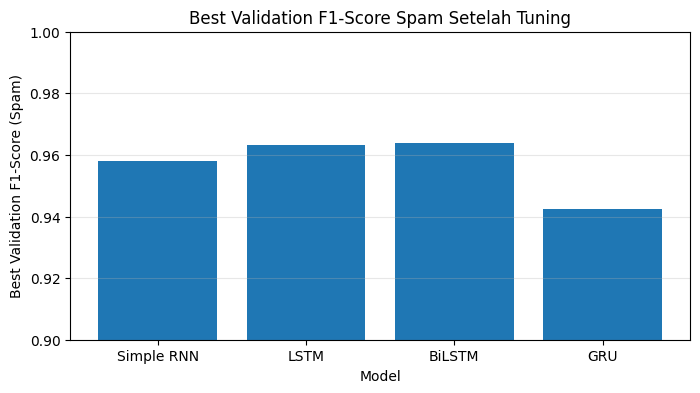

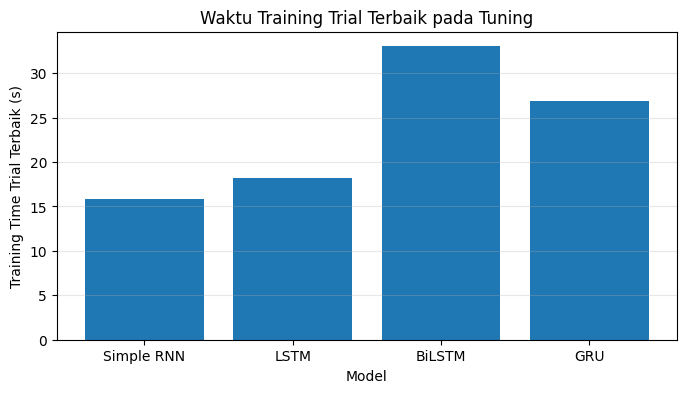

In [47]:
plt.figure(figsize=(8, 4))
plt.bar(best_tuning_records["Model"], best_tuning_records["Val F1-Score (Spam)"])
plt.title("Best Validation F1-Score Spam Setelah Tuning")
plt.xlabel("Model")
plt.ylabel("Best Validation F1-Score (Spam)")
plt.ylim(0.9, 1.0)
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(best_tuning_records["Model"], best_tuning_records["Training Time (s)"])
plt.title("Waktu Training Trial Terbaik pada Tuning")
plt.xlabel("Model")
plt.ylabel("Training Time Trial Terbaik (s)")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 24. Retraining Model dengan Hyperparameter Terbaik

Setelah hyperparameter terbaik tiap model ditemukan dari validation set, setiap model ditrain ulang menggunakan konfigurasi terbaiknya masing-masing. Evaluasi akhir kemudian dilakukan pada test set.

Langkah retraining ini penting karena hasil tuning pada validation set belum tentu selalu sama dengan hasil pada test set. Oleh karena itu, performa final harus tetap dibaca dari hasil evaluasi test set, bukan hanya dari skor validation saat tuning.


In [48]:
def extract_best_params(best_record):
    param_keys = [
        "embedding_dim",
        "rnn_units",
        "dense_units",
        "embedding_dropout_rate",
        "rnn_dropout_rate",
        "dense_dropout_rate",
        "learning_rate",
        "batch_size"
    ]
    return {key: best_record[key] for key in param_keys}


BEST_PARAMS_BY_MODEL = {
    "Simple RNN": extract_best_params(simple_rnn_best),
    "LSTM": extract_best_params(lstm_best),
    "BiLSTM": extract_best_params(bilstm_best),
    "GRU": extract_best_params(gru_best)
}

BEST_PARAMS_BY_MODEL

{'Simple RNN': {'embedding_dim': 32,
  'rnn_units': 64,
  'dense_units': 32,
  'embedding_dropout_rate': 0.1,
  'rnn_dropout_rate': 0.2,
  'dense_dropout_rate': 0.3,
  'learning_rate': 0.001,
  'batch_size': 32},
 'LSTM': {'embedding_dim': 64,
  'rnn_units': 32,
  'dense_units': 32,
  'embedding_dropout_rate': 0.15,
  'rnn_dropout_rate': 0.3,
  'dense_dropout_rate': 0.3,
  'learning_rate': 0.001,
  'batch_size': 64},
 'BiLSTM': {'embedding_dim': 64,
  'rnn_units': 32,
  'dense_units': 32,
  'embedding_dropout_rate': 0.15,
  'rnn_dropout_rate': 0.3,
  'dense_dropout_rate': 0.3,
  'learning_rate': 0.001,
  'batch_size': 64},
 'GRU': {'embedding_dim': 64,
  'rnn_units': 64,
  'dense_units': 32,
  'embedding_dropout_rate': 0.15,
  'rnn_dropout_rate': 0.3,
  'dense_dropout_rate': 0.3,
  'learning_rate': 0.0005,
  'batch_size': 32}}

Retraining tuned model: Simple RNN


Model: "simple_rnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 32)    │    160,000 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_dropout   │ (None, 50, 32)    │          0 │ embedding[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 50)        │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 64)        │      6,208 │ embedding_dropou… │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_hidden        │ (None, 32)        │      2,080 │ simple_rnn[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_dropout       │ (None, 32)        │          0 │ dense_hidden[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dense_dropout[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 168,321 (657.50 KB)

 Trainable params: 168,321 (657.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7676 - loss: 0.4626 - val_accuracy: 0.9729 - val_loss: 0.0838
Epoch 2/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9778 - loss: 0.0791 - val_accuracy: 0.9845 - val_loss: 0.0593
Epoch 3/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9909 - loss: 0.0355 - val_accuracy: 0.9755 - val_loss: 0.1091
Epoch 4/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9940 - loss: 0.0256 - val_accuracy: 0.9768 - val_loss: 0.0818
Epoch 5/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9956 - loss: 0.0151 - val_accuracy: 0.9806 - val_loss: 0.0643
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

Training time tuned Simple RNN: 12.79 seconds


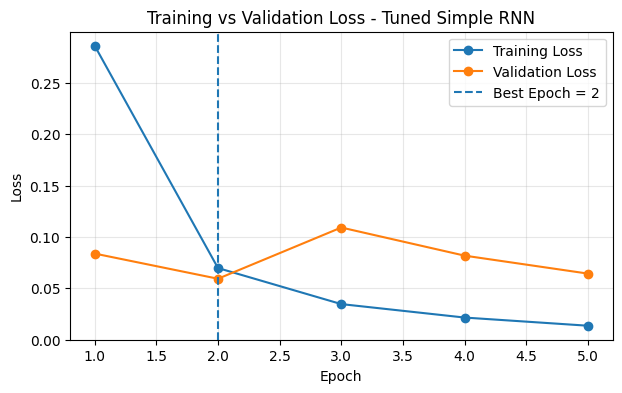

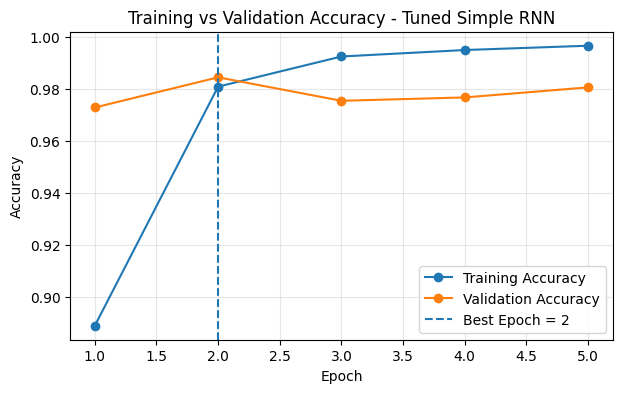


Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       678
        spam       0.95      0.94      0.94        98

    accuracy                           0.99       776
   macro avg       0.97      0.97      0.97       776
weighted avg       0.99      0.99      0.99       776

Confusion Matrix:


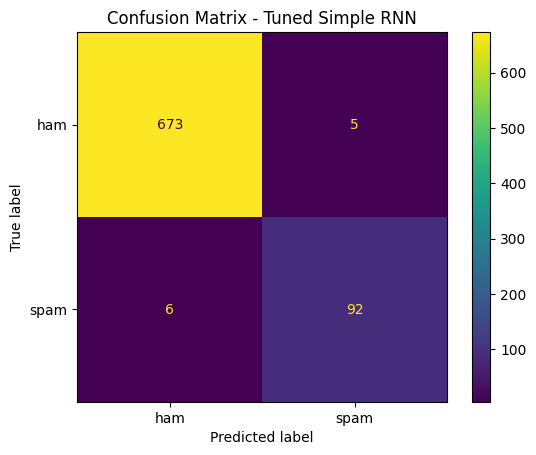

Distribusi prediksi pada test set:
- Actual spam rate    : 0.1263
- Predicted spam rate : 0.1250
- Predicted ham       : 679
- Predicted spam      : 97

Diagnosis training: Relatif stabil
Best epoch berdasarkan validation loss: 2
Catatan: evaluasi memakai bobot terbaik karena restore_best_weights=True.
Retraining tuned model: LSTM


Model: "lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 64)    │    320,000 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_dropout   │ (None, 50, 64)    │          0 │ embedding[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 50)        │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │     12,416 │ embedding_dropou… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_hidden        │ (None, 32)        │      1,056 │ lstm[0][0]        │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_dropout       │ (None, 32)        │          0 │ dense_hidden[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dense_dropout[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 333,505 (1.27 MB)

 Trainable params: 333,505 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.7871 - loss: 0.5910 - val_accuracy: 0.9639 - val_loss: 0.1480
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9727 - loss: 0.1190 - val_accuracy: 0.9832 - val_loss: 0.0580
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9851 - loss: 0.0523 - val_accuracy: 0.9871 - val_loss: 0.0466
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9935 - loss: 0.0341 - val_accuracy: 0.9858 - val_loss: 0.0473
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9945 - loss: 0.0221 - val_accuracy: 0.9858 - val_loss: 0.0498
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9965 - loss: 0.0138 - val_accuracy: 0.9845 - val_loss: 0.0583
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.

Training time tuned LSTM: 13.78 seconds


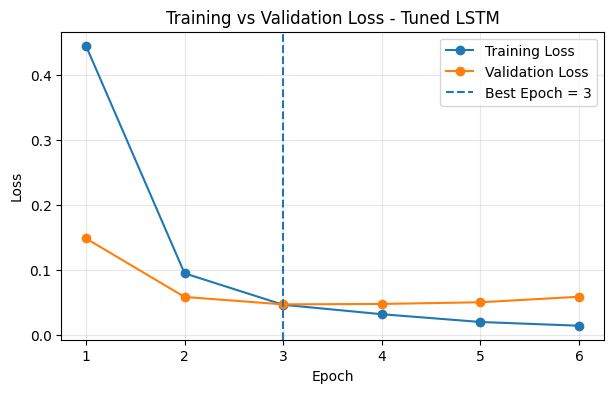

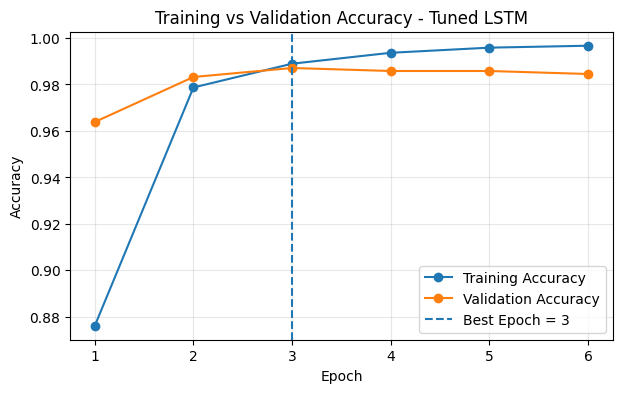


Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       678
        spam       0.94      0.95      0.94        98

    accuracy                           0.99       776
   macro avg       0.97      0.97      0.97       776
weighted avg       0.99      0.99      0.99       776

Confusion Matrix:


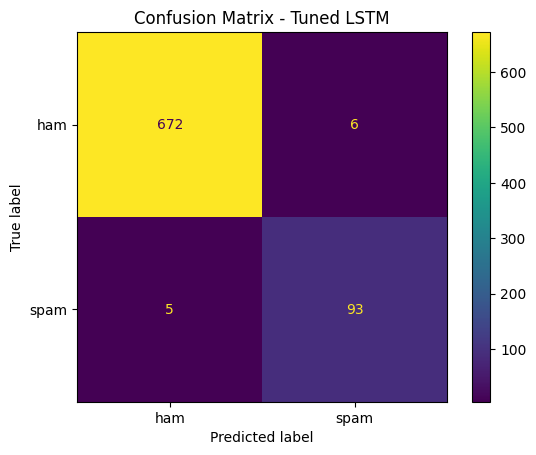

Distribusi prediksi pada test set:
- Actual spam rate    : 0.1263
- Predicted spam rate : 0.1276
- Predicted ham       : 677
- Predicted spam      : 99

Diagnosis training: Ada indikasi overfitting, dikontrol EarlyStopping
Best epoch berdasarkan validation loss: 3
Catatan: evaluasi memakai bobot terbaik karena restore_best_weights=True.
Retraining tuned model: BiLSTM


Model: "bilstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 64)    │    320,000 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_dropout   │ (None, 50, 64)    │          0 │ embedding[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 50)        │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 64)        │     24,832 │ embedding_dropou… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_hidden        │ (None, 32)        │      2,080 │ bilstm[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_dropout       │ (None, 32)        │          0 │ dense_hidden[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dense_dropout[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 346,945 (1.32 MB)

 Trainable params: 346,945 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.7979 - loss: 0.5777 - val_accuracy: 0.9639 - val_loss: 0.1273
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9741 - loss: 0.1022 - val_accuracy: 0.9819 - val_loss: 0.0582
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9885 - loss: 0.0432 - val_accuracy: 0.9858 - val_loss: 0.0515
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9932 - loss: 0.0257 - val_accuracy: 0.9884 - val_loss: 0.0529
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9958 - loss: 0.0153 - val_accuracy: 0.9845 - val_loss: 0.0582
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9982 - loss: 0.0109 - val_accuracy: 0.9884 - val_loss: 0.0443
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9991 - loss: 0.0056 - val_accuracy: 0.9884 - val_loss: 0.0476
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9991 - loss: 0.0036 - val_accuracy: 0.9871 - v

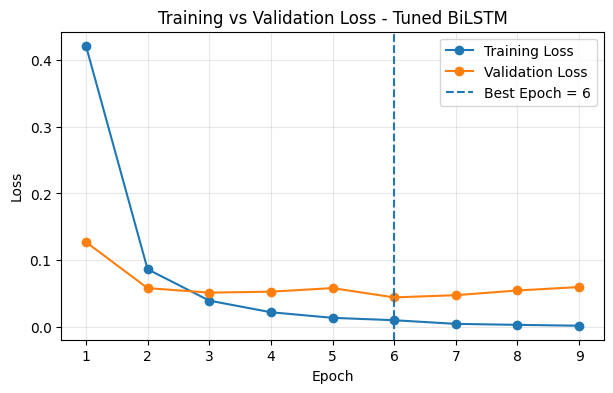

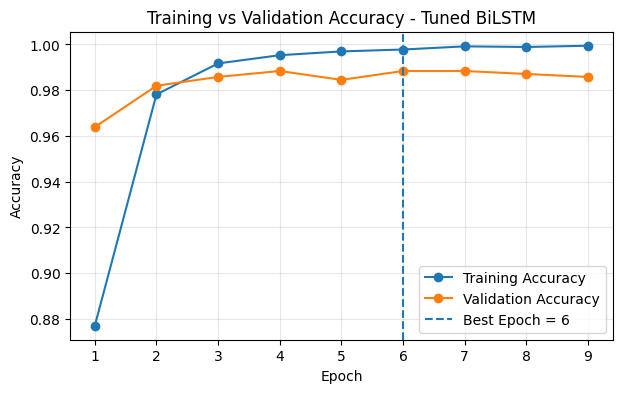


Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       678
        spam       0.94      0.96      0.95        98

    accuracy                           0.99       776
   macro avg       0.97      0.98      0.97       776
weighted avg       0.99      0.99      0.99       776

Confusion Matrix:


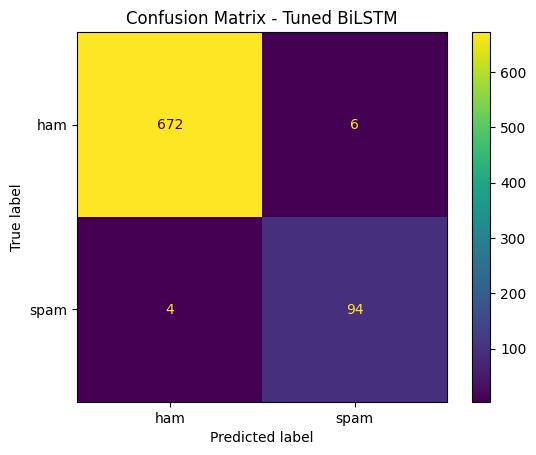

Distribusi prediksi pada test set:
- Actual spam rate    : 0.1263
- Predicted spam rate : 0.1289
- Predicted ham       : 676
- Predicted spam      : 100

Diagnosis training: Ada indikasi overfitting, dikontrol EarlyStopping
Best epoch berdasarkan validation loss: 6
Catatan: evaluasi memakai bobot terbaik karena restore_best_weights=True.
Retraining tuned model: GRU


Model: "gru"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 64)    │    320,000 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_dropout   │ (None, 50, 64)    │          0 │ embedding[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 50)        │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 64)        │     24,960 │ embedding_dropou… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_hidden        │ (None, 32)        │      2,080 │ gru[0][0]         │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_dropout       │ (None, 32)        │          0 │ dense_hidden[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dense_dropout[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 347,073 (1.32 MB)

 Trainable params: 347,073 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.7938 - loss: 0.5552 - val_accuracy: 0.9652 - val_loss: 0.1229
Epoch 2/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9697 - loss: 0.1103 - val_accuracy: 0.9794 - val_loss: 0.0653
Epoch 3/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9874 - loss: 0.0563 - val_accuracy: 0.9832 - val_loss: 0.0545
Epoch 4/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9921 - loss: 0.0383 - val_accuracy: 0.9832 - val_loss: 0.0565
Epoch 5/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9930 - loss: 0.0246 - val_accuracy: 0.9819 - val_loss: 0.0671
Epoch 6/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9956 - loss: 0.0150 - val_accuracy: 0.9806 - val_loss: 0.0670
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.

Training time tuned GRU: 24.40 seconds


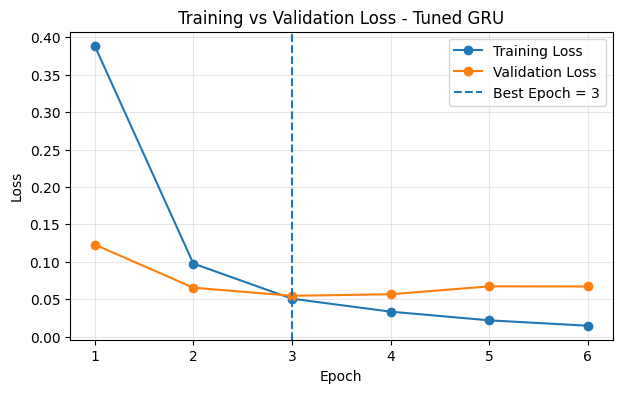

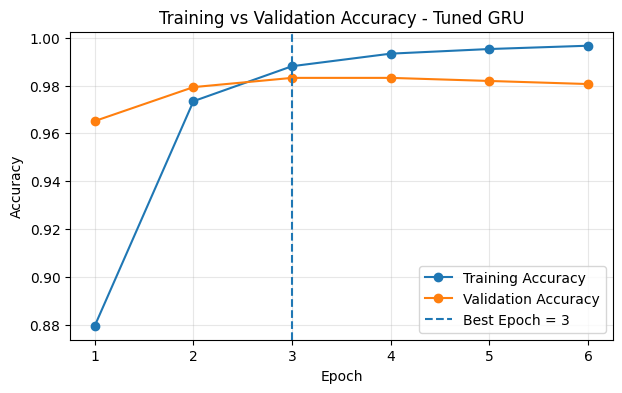


Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       678
        spam       0.94      0.93      0.93        98

    accuracy                           0.98       776
   macro avg       0.96      0.96      0.96       776
weighted avg       0.98      0.98      0.98       776

Confusion Matrix:


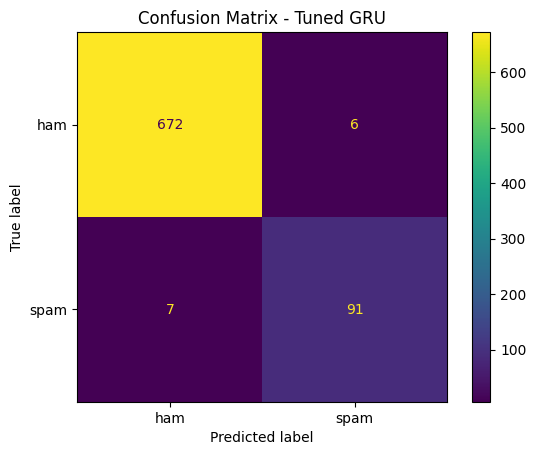

Distribusi prediksi pada test set:
- Actual spam rate    : 0.1263
- Predicted spam rate : 0.1250
- Predicted ham       : 679
- Predicted spam      : 97

Diagnosis training: Ada indikasi overfitting, dikontrol EarlyStopping
Best epoch berdasarkan validation loss: 3
Catatan: evaluasi memakai bobot terbaik karena restore_best_weights=True.


In [49]:
def run_tuned_experiment(model_type, best_params):
    print("=" * 80)
    print(f"Retraining tuned model: {model_type}")
    print("=" * 80)

    tf.keras.backend.clear_session()
    set_global_seed(RANDOM_STATE)

    tuned_config = make_trial_config(best_params)

    model = build_sequence_model(model_type, tuned_config)
    model.summary()

    start_time = time.time()

    history = model.fit(
        X_train_pad,
        y_train,
        validation_data=(X_val_pad, y_val),
        epochs=tuned_config["epochs"],
        batch_size=tuned_config["batch_size"],
        callbacks=get_callbacks(tuned_config),
        verbose=1
    )

    train_time = time.time() - start_time

    print(f"\nTraining time tuned {model_type}: {train_time:.2f} seconds")

    plot_training_history(history, f"Tuned {model_type}")

    result = evaluate_model(
        model=model,
        history=history,
        model_name=model_type,
        train_time=train_time,
        config=tuned_config,
        experiment_type="Tuned"
    )

    tuned_histories[model_type] = history
    tuned_models[model_type] = model
    tuned_results.append(result)

    return model, history, result


tuned_histories = {}
tuned_models = {}
tuned_results = []

for model_type in MODEL_TYPES:
    run_tuned_experiment(model_type, BEST_PARAMS_BY_MODEL[model_type])

## 25. Evaluasi Semua Tuned Model

Setelah retraining, semua tuned model dievaluasi pada test set yang sama. Berdasarkan output, seluruh tuned model menghasilkan performa yang sehat dan tidak collapse ke satu kelas.

Hasil utama tuned model adalah:

- **Tuned BiLSTM** memperoleh F1-score spam tertinggi, yaitu **0.9495**;
- **Tuned BiLSTM** juga memperoleh recall spam tertinggi, yaitu **0.9592**;
- **Tuned Simple RNN** menjadi model paling stabil dan tercepat dengan F1-score spam **0.9436**;
- **Tuned LSTM** memperoleh F1-score spam **0.9442**, sedikit lebih tinggi dari Tuned Simple RNN;
- **Tuned GRU** meningkat dibanding baseline, tetapi masih menjadi tuned model dengan F1-score paling rendah.

Predicted spam rate semua tuned model tetap dekat dengan actual spam rate, sehingga hasilnya dapat dianggap stabil.


In [52]:
tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df = tuned_results_df[baseline_metric_columns].copy()

rounded_tuned_results_df = tuned_results_df.copy()
numeric_cols = rounded_tuned_results_df.select_dtypes(include=["float64", "float32"]).columns
rounded_tuned_results_df[numeric_cols] = rounded_tuned_results_df[numeric_cols].round(4)

display(rounded_tuned_results_df)

tuned_results_df.to_csv("tuned_results.csv", index=False)
print("Hasil tuned model disimpan ke tuned_results.csv")

,Experiment Type,Model,Test Accuracy,Precision (Spam),Recall (Spam),F1-Score (Spam),Validation Loss (Restored Best Weights),Test Loss,Training Time (s),Epochs Run,Predicted Spam Rate,Actual Spam Rate,Best Epoch,Best Val Loss,Best Loss Gap,Epochs After Best,Val Loss Worsening Ratio,Training Diagnosis
0,Tuned,Simple RNN,0.9858,0.9485,0.9388,0.9436,0.0593,0.0518,12.7861,5,0.1250,0.1263,2,0.0593,-0.0104,3,1.0845,Relatif stabil
1,Tuned,LSTM,0.9858,0.9394,0.9490,0.9442,0.0466,0.0608,13.7799,6,0.1276,0.1263,3,0.0466,0.0006,3,1.2524,"Ada indikasi overfitting, dikontrol EarlyStopping"
2,Tuned,BiLSTM,0.9871,0.9400,0.9592,0.9495,0.0443,0.0458,26.3837,9,0.1289,0.1263,6,0.0443,0.0342,3,1.3512,"Ada indikasi overfitting, dikontrol EarlyStopping"
3,Tuned,GRU,0.9832,0.9381,0.9286,0.9333,0.0545,0.0633,24.3978,6,0.1250,0.1263,3,0.0545,0.0039,3,1.2284,"Ada indikasi overfitting, dikontrol EarlyStopping"


Hasil tuned model disimpan ke tuned_results.csv


### Interpretasi Tabel Tuned Model

Evaluasi test set menunjukkan bahwa **Tuned BiLSTM** adalah tuned model terbaik. Model ini memperoleh accuracy **0.9871**, recall spam **0.9592**, dan F1-score spam **0.9495**. Recall yang tinggi berarti model ini paling baik dalam menangkap pesan spam pada test set.

**Tuned LSTM** memperoleh F1-score spam **0.9442**, sedikit lebih tinggi dari **Tuned Simple RNN** dengan F1-score **0.9436**. Perbedaannya sangat kecil, sehingga keduanya dapat dianggap cukup kompetitif.

**Tuned GRU** memperoleh F1-score spam **0.9333**. Nilai ini meningkat dari baseline GRU, tetapi masih berada di bawah tuned model lain.

Poin penting: seluruh tuned model memiliki predicted spam rate yang dekat dengan actual spam rate sekitar **0.1263**. Artinya, tidak ada tuned model yang collapse menjadi model yang hanya memprediksi spam atau ham.


## 26. Perbandingan Baseline vs Tuned Model

Perbandingan baseline vs tuned model menunjukkan bahwa tuning meningkatkan F1-score spam untuk semua model, tetapi peningkatannya tidak sama besar.

Peningkatan F1-score spam adalah:

- Simple RNN: naik dari **0.9239** menjadi **0.9436** atau meningkat **0.0197**;
- LSTM: naik dari **0.9388** menjadi **0.9442** atau meningkat **0.0054**;
- BiLSTM: naik dari **0.9430** menjadi **0.9495** atau meningkat **0.0065**;
- GRU: naik dari **0.9293** menjadi **0.9333** atau meningkat **0.0040**.

Interpretasi pentingnya: tuning paling banyak membantu Simple RNN, sedangkan peningkatan pada LSTM, BiLSTM, dan GRU relatif kecil karena baseline model-model tersebut sudah cukup kuat.


In [53]:
final_comparison_df = pd.concat(
    [baseline_results_df, tuned_results_df],
    ignore_index=True
)

rounded_final_comparison_df = final_comparison_df.copy()
numeric_cols = rounded_final_comparison_df.select_dtypes(include=["float64", "float32"]).columns
rounded_final_comparison_df[numeric_cols] = rounded_final_comparison_df[numeric_cols].round(4)

display(rounded_final_comparison_df)

final_comparison_df.to_csv("baseline_vs_tuned_comparison.csv", index=False)
print("Perbandingan baseline vs tuned disimpan ke baseline_vs_tuned_comparison.csv")

,Experiment Type,Model,Test Accuracy,Precision (Spam),Recall (Spam),F1-Score (Spam),Validation Loss (Restored Best Weights),Test Loss,Training Time (s),Epochs Run,Predicted Spam Rate,Actual Spam Rate,Best Epoch,Best Val Loss,Best Loss Gap,Epochs After Best,Val Loss Worsening Ratio,Training Diagnosis
0,Baseline,Simple RNN,0.9807,0.9192,0.9286,0.9239,0.0572,0.0732,17.6668,8,0.1276,0.1263,5,0.0572,0.0177,3,1.1954,Relatif stabil
1,Baseline,LSTM,0.9845,0.9388,0.9388,0.9388,0.0455,0.0555,25.9761,8,0.1263,0.1263,5,0.0455,0.0211,3,1.4898,"Ada indikasi overfitting, dikontrol EarlyStopping"
2,Baseline,BiLSTM,0.9858,0.9579,0.9286,0.9430,0.0435,0.0441,32.6371,7,0.1224,0.1263,4,0.0435,0.0200,3,2.9762,"Ada indikasi overfitting, dikontrol EarlyStopping"
3,Baseline,GRU,0.9820,0.9200,0.9388,0.9293,0.0548,0.0703,20.8010,6,0.1289,0.1263,3,0.0548,0.0082,3,1.3998,"Ada indikasi overfitting, dikontrol EarlyStopping"
4,Tuned,Simple RNN,0.9858,0.9485,0.9388,0.9436,0.0593,0.0518,12.7861,5,0.1250,0.1263,2,0.0593,-0.0104,3,1.0845,Relatif stabil
5,Tuned,LSTM,0.9858,0.9394,0.9490,0.9442,0.0466,0.0608,13.7799,6,0.1276,0.1263,3,0.0466,0.0006,3,1.2524,"Ada indikasi overfitting, dikontrol EarlyStopping"
6,Tuned,BiLSTM,0.9871,0.9400,0.9592,0.9495,0.0443,0.0458,26.3837,9,0.1289,0.1263,6,0.0443,0.0342,3,1.3512,"Ada indikasi overfitting, dikontrol EarlyStopping"
7,Tuned,GRU,0.9832,0.9381,0.9286,0.9333,0.0545,0.0633,24.3978,6,0.1250,0.1263,3,0.0545,0.0039,3,1.2284,"Ada indikasi overfitting, dikontrol EarlyStopping"


Perbandingan baseline vs tuned disimpan ke baseline_vs_tuned_comparison.csv


In [54]:
comparison_pivot = final_comparison_df.pivot(index="Model", columns="Experiment Type", values="F1-Score (Spam)")
comparison_pivot["Improvement"] = comparison_pivot.get("Tuned", np.nan) - comparison_pivot.get("Baseline", np.nan)

display(comparison_pivot.round(4))

Experiment Type,Baseline,Tuned,Improvement
Model,,,
BiLSTM,0.9430,0.9495,0.0065
GRU,0.9293,0.9333,0.0040
LSTM,0.9388,0.9442,0.0054
Simple RNN,0.9239,0.9436,0.0197


### Interpretasi Improvement Baseline ke Tuned

Tuning meningkatkan F1-score spam pada semua model, tetapi skala peningkatannya berbeda.

Peningkatan terbesar terjadi pada **Simple RNN**, yaitu **+0.0197**. Ini menunjukkan bahwa Simple RNN paling terbantu oleh tuning. Kemungkinan karena baseline Simple RNN masih memiliki ruang perbaikan yang lebih besar dibanding model lain.

Peningkatan pada **BiLSTM** sebesar **+0.0065**, **LSTM** sebesar **+0.0054**, dan **GRU** sebesar **+0.0040**. Peningkatan ini relatif kecil, tetapi tetap positif. Artinya, tuning membantu, tetapi baseline awal sebenarnya sudah cukup kuat.

Kesimpulan yang perlu ditulis secara hati-hati: tuning tidak mengubah ranking performa secara ekstrem. BiLSTM tetap menjadi model paling kuat, sedangkan GRU tetap tidak mengungguli LSTM atau BiLSTM.


<Figure size 800x400 with 0 Axes>

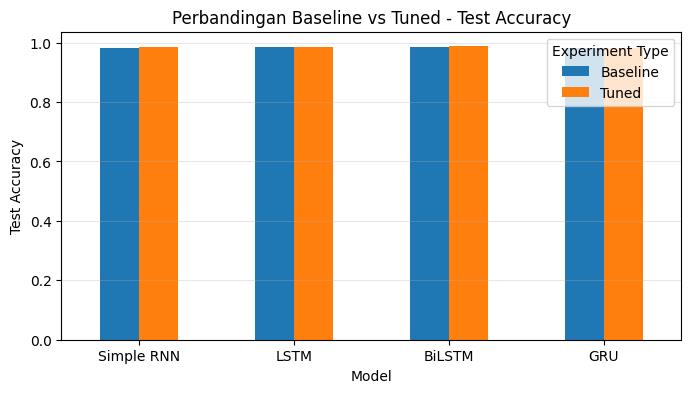

<Figure size 800x400 with 0 Axes>

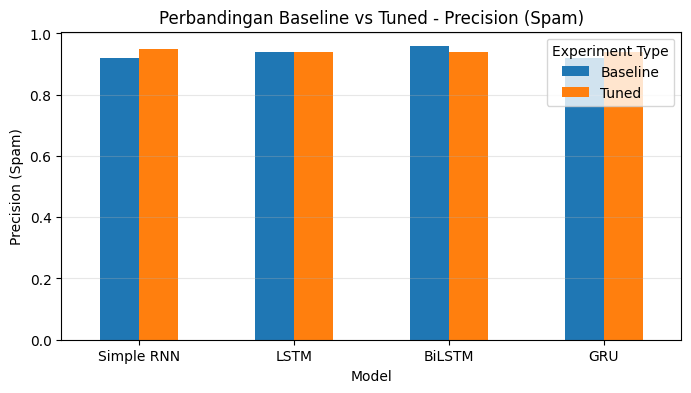

<Figure size 800x400 with 0 Axes>

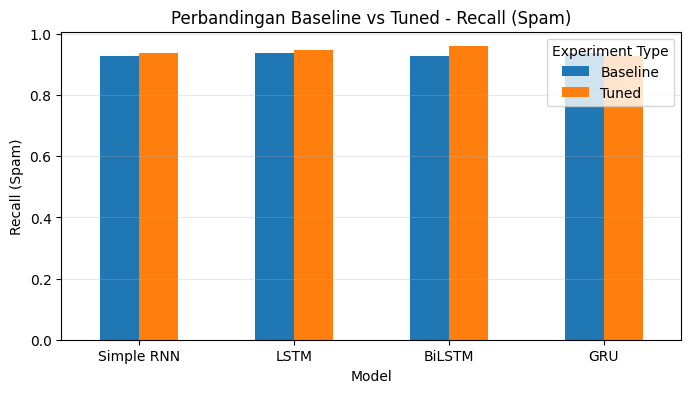

<Figure size 800x400 with 0 Axes>

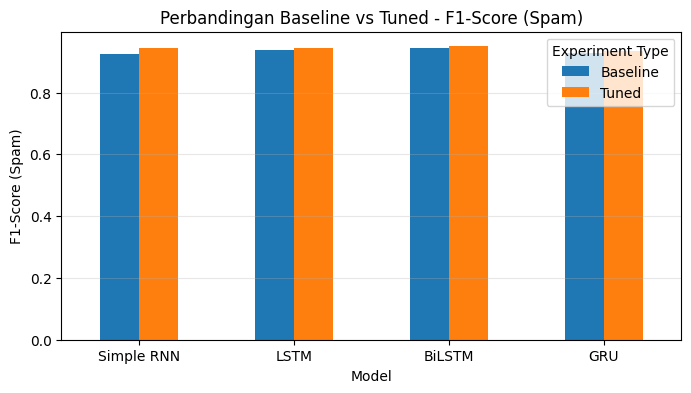

<Figure size 800x400 with 0 Axes>

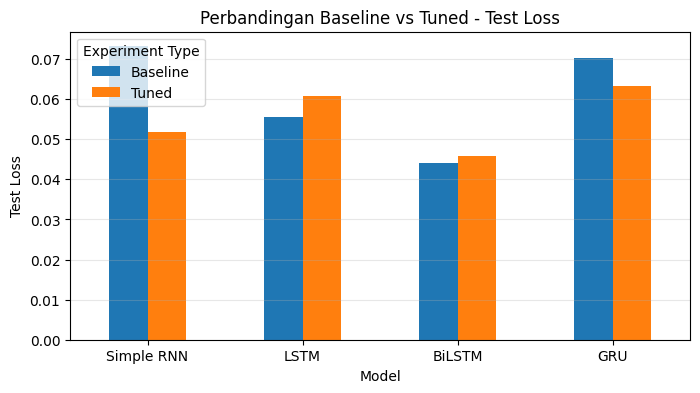

<Figure size 800x400 with 0 Axes>

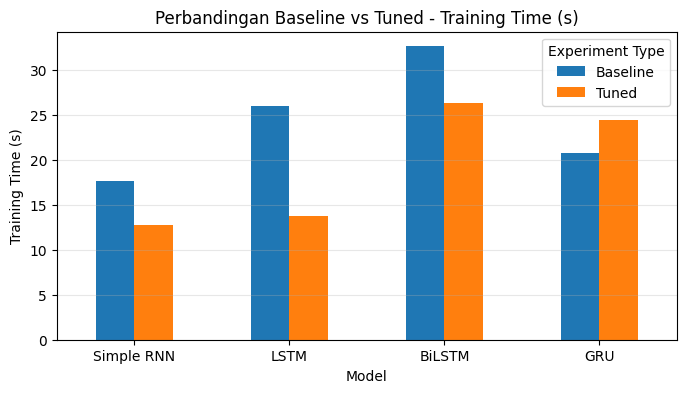

In [55]:
metrics_to_plot = [
    "Test Accuracy",
    "Precision (Spam)",
    "Recall (Spam)",
    "F1-Score (Spam)",
    "Test Loss",
    "Training Time (s)"
]

for metric in metrics_to_plot:
    pivot_df = final_comparison_df.pivot(index="Model", columns="Experiment Type", values=metric)
    pivot_df = pivot_df.reindex(MODEL_TYPES)

    plt.figure(figsize=(8, 4))
    pivot_df.plot(kind="bar", figsize=(8, 4))
    plt.title(f"Perbandingan Baseline vs Tuned - {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=0)
    plt.show()

## 27. Pemilihan Model Final

Pemilihan model final tidak hanya berdasarkan accuracy. Karena dataset imbalanced, prioritas utama adalah F1-score spam dan recall spam. Precision tetap penting, tetapi dalam konteks spam detection, recall spam juga sangat penting karena spam yang lolos sebagai ham dapat merugikan pengguna.

Berdasarkan output final, kandidat model terbaik adalah **Tuned BiLSTM** karena memperoleh:

- test accuracy tertinggi: **0.9871**;
- recall spam tertinggi: **0.9592**;
- F1-score spam tertinggi: **0.9495**.

Namun, terdapat trade-off yang perlu dicatat. Test loss terendah justru diperoleh oleh **Baseline BiLSTM** sebesar **0.0441**, sedikit lebih rendah daripada Tuned BiLSTM sebesar **0.0458**. Artinya, tuning meningkatkan F1-score dan recall, tetapi tidak memperbaiki test loss. Karena itu, Tuned BiLSTM dapat dipilih sebagai model final jika prioritasnya adalah deteksi spam, sedangkan Baseline BiLSTM tetap menjadi alternatif yang sangat kuat jika prioritasnya loss dan kesederhanaan eksperimen.


In [56]:
print_best_models(final_comparison_df, title="Ringkasan Final Baseline vs Tuned")

best_final_model = final_comparison_df.loc[final_comparison_df["F1-Score (Spam)"].idxmax()]

print("\nKandidat model final berdasarkan F1-score spam tertinggi:")
display(best_final_model.to_frame().T)

Ringkasan Final Baseline vs Tuned
F1-score spam tertinggi: BiLSTM (F1-Score (Spam) = 0.9495)
Recall spam tertinggi: BiLSTM (Recall (Spam) = 0.9592)
Precision spam tertinggi: BiLSTM (Precision (Spam) = 0.9579)
Test loss terendah: BiLSTM (Test Loss = 0.0441)
Training time tercepat: Simple RNN (Training Time (s) = 12.7861)

Kandidat model final berdasarkan F1-score spam tertinggi:


,Experiment Type,Model,Test Accuracy,Precision (Spam),Recall (Spam),F1-Score (Spam),Validation Loss (Restored Best Weights),Test Loss,Training Time (s),Epochs Run,Predicted Spam Rate,Actual Spam Rate,Best Epoch,Best Val Loss,Best Loss Gap,Epochs After Best,Val Loss Worsening Ratio,Training Diagnosis
6,Tuned,BiLSTM,0.987113,0.94,0.959184,0.949495,0.044268,0.045808,26.383736,9,0.128866,0.126289,6,0.044268,0.034178,3,1.351195,"Ada indikasi overfitting, dikontrol EarlyStopping"


In [57]:
def generate_final_interpretation(final_df):
    best_f1 = final_df.loc[final_df["F1-Score (Spam)"].idxmax()]
    best_loss = final_df.loc[final_df["Test Loss"].idxmin()]
    fastest = final_df.loc[final_df["Training Time (s)"].idxmin()]

    print("Interpretasi otomatis berdasarkan output:")
    print("-" * 80)
    print(
        f"Model dengan F1-score spam tertinggi adalah {best_f1['Experiment Type']} {best_f1['Model']} "
        f"dengan F1-score {best_f1['F1-Score (Spam)']:.4f}."
    )
    print(
        f"Model dengan test loss terendah adalah {best_loss['Experiment Type']} {best_loss['Model']} "
        f"dengan test loss {best_loss['Test Loss']:.4f}."
    )
    print(
        f"Model dengan waktu training tercepat adalah {fastest['Experiment Type']} {fastest['Model']} "
        f"dengan waktu {fastest['Training Time (s)']:.2f} detik."
    )

    print("\nCatatan analisis:")
    print(
        "Jika tuned model hanya meningkatkan F1-score sedikit tetapi waktu training jauh lebih lama, "
        "maka peningkatan tersebut perlu dibaca sebagai trade-off, bukan kemenangan mutlak."
    )
    print(
        "Jika baseline sudah sangat tinggi dan tuning tidak memberi peningkatan besar, "
        "itu berarti konfigurasi baseline sudah cukup kuat untuk dataset ini."
    )

generate_final_interpretation(final_comparison_df)

Interpretasi otomatis berdasarkan output:
--------------------------------------------------------------------------------
Model dengan F1-score spam tertinggi adalah Tuned BiLSTM dengan F1-score 0.9495.
Model dengan test loss terendah adalah Baseline BiLSTM dengan test loss 0.0441.
Model dengan waktu training tercepat adalah Tuned Simple RNN dengan waktu 12.79 detik.

Catatan analisis:
Jika tuned model hanya meningkatkan F1-score sedikit tetapi waktu training jauh lebih lama, maka peningkatan tersebut perlu dibaca sebagai trade-off, bukan kemenangan mutlak.
Jika baseline sudah sangat tinggi dan tuning tidak memberi peningkatan besar, itu berarti konfigurasi baseline sudah cukup kuat untuk dataset ini.


### Interpretasi Final Berdasarkan Output Otomatis

Output otomatis menunjukkan tiga fakta penting:

1. **F1-score spam tertinggi** diperoleh oleh **Tuned BiLSTM** dengan nilai **0.9495**.
2. **Test loss terendah** diperoleh oleh **Baseline BiLSTM** dengan nilai **0.0441**.
3. **Training time tercepat** diperoleh oleh **Tuned Simple RNN** dengan waktu sekitar **12.79 detik**.

Artinya, tidak ada satu model yang menang mutlak pada semua aspek. Jika prioritas utama adalah deteksi spam berdasarkan F1-score dan recall, maka **Tuned BiLSTM** paling layak dipilih sebagai model final. Jika prioritasnya test loss paling rendah dan performa yang sudah sangat kuat tanpa tuning, **Baseline BiLSTM** tetap sangat baik. Jika prioritasnya efisiensi waktu training, **Tuned Simple RNN** menjadi alternatif paling ringan.


## 28. Kesimpulan

Berdasarkan seluruh eksperimen, model terbaik secara keseluruhan adalah **Tuned BiLSTM**. Model ini memperoleh F1-score spam tertinggi sebesar **0.9495** dan recall spam tertinggi sebesar **0.9592** pada test set. Hasil ini menunjukkan bahwa tuning terarah mampu meningkatkan kemampuan model dalam mendeteksi kelas spam.

Namun, peningkatan tuning tidak terlalu besar pada semua model. Baseline BiLSTM sudah sangat kuat dengan F1-score spam **0.9430** dan test loss terendah **0.0441**. Setelah tuning, BiLSTM meningkatkan F1-score menjadi **0.9495**, tetapi test loss sedikit naik menjadi **0.0458**. Oleh karena itu, tuning perlu dibaca sebagai peningkatan pada metrik klasifikasi spam, bukan peningkatan mutlak di semua aspek.

Secara ringkas:

- **Tuned BiLSTM** adalah model final terbaik jika prioritas utama adalah F1-score dan recall spam.
- **Baseline BiLSTM** tetap sangat kompetitif karena memiliki test loss terendah dan precision spam tertinggi.
- **Tuned Simple RNN** menunjukkan peningkatan paling besar dari baseline, sehingga tuning paling membantu model ini.
- **LSTM** tetap menjadi alternatif yang seimbang antara performa dan waktu training.
- **GRU** membaik setelah tuning, tetapi tidak mengungguli LSTM atau BiLSTM pada output ini.

Eksperimen ini juga menunjukkan bahwa EarlyStopping berhasil mengontrol overfitting. Beberapa model memiliki indikasi overfitting dari training history, tetapi model akhir menggunakan bobot terbaik berdasarkan validation loss, sehingga performa test tetap stabil.


## 29. Catatan Penting untuk Laporan

Beberapa hal yang perlu dijaga saat menulis laporan:

- Jangan menyimpulkan model terbaik hanya dari accuracy.
- Gunakan F1-score spam dan recall spam sebagai metrik utama karena dataset imbalanced.
- Jelaskan bahwa tuning dilakukan secara terarah, bukan exhaustive, karena dataset relatif kecil.
- Jelaskan bahwa Tuned BiLSTM unggul pada F1-score dan recall, tetapi Baseline BiLSTM memiliki test loss terendah.
- Jangan mengklaim tuning selalu memperbaiki semua metrik. Pada output ini, tuning memperbaiki F1-score semua model, tetapi tidak selalu menurunkan test loss.
- Tekankan bahwa tidak ada model yang collapse ke satu kelas karena predicted spam rate semua model dekat dengan actual spam rate.
- Jelaskan bahwa grafik train-validation yang menjauh menunjukkan indikasi overfitting, tetapi EarlyStopping dengan `restore_best_weights=True` membantu memilih bobot terbaik.
